* [Página do Desafio](https://github.com/rfordatascience/tidytuesday/tree/main/data/2026/2026-04-21)

# O que é o **GHED**?
A **WHO Global Health Expenditure Database** é uma das bases mais completas do mundo sobre como países financiam saúde. Ela cobre dimensões como:

* Gastos totais com saúde como % do PIB
* Out-of-pocket expenses: o quanto as pessoas pagam do próprio bolso
* Gastos governamentais vs. privados
* Cobertura por país e período

# Importações

In [1]:
!pip install streamlit world_bank_data -q

# Bibliotecas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import world_bank_data as wb

import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 48.9 MB/s eta 0:00:00


# Carregando Dados

In [2]:
# Baixando arquivos do desafio
BASE_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-04-21"

health_spending = pd.read_csv(f"{BASE_URL}/health_spending.csv")
financing_schemes = pd.read_csv(f"{BASE_URL}/financing_schemes.csv")
spending_purpose = pd.read_csv(f"{BASE_URL}/spending_purpose.csv")

In [3]:
# Dados populacionais
## Buscando pelo código ISO3

pop_paises  = [
    'BRA', 'RUS', 'IND', 'CHN', 'ZAF',
    'FRA', 'ESP', 'GBR', 'CAN', 'URY', 'SWE', 'PRT', 'AUS'
    ]

df_pop = wb.get_series(
        'SP.POP.TOTL',
        country=pop_paises,
        date='2000:2023'
        ).reset_index()

df_pop.sample(5)

,Country,Series,Year,SP.POP.TOTL
75,China,"Population, total",2003,1288400000
165,United Kingdom,"Population, total",2021,66984000
177,India,"Population, total",2009,1225524753
100,Spain,"Population, total",2004,42921895
311,South Africa,"Population, total",2023,63212384


# Configurações Globais

## Paleta de Cores

In [4]:
# Paleta semantica global
CORES = {
    "governo":  "#1f77b4",  # azul    — gasto publico / SUS
    "privado":  "#ff7f0e",  # laranja — setor privado / planos
    "oop":      "#d62728",  # vermelho — desembolso direto (alerta)
    "externo":  "#2ca02c",  # verde   — ajuda externa
    "outro":    "#999999",  # cinza   — nao identificado / outros

    # Paleta por pais — BRICS fundadores
    "Brasil":        "#f4c300",
    "Rússia":        "#0039a6",
    "Índia":         "#ff9933",
    "China":         "#de2910",
    "África do Sul": "#007749",

    # Paleta por pais — sistemas universais
    "Brasil_univ":   "#c9a000",
    "França":        "#3b5aa3",
    "Espanha":       "#e67e22",
    "Reino Unido":   "#b22222",
    "Canadá":        "#8b0000",
    "Uruguai":       "#5dade2",
    "Portugal":      "#006600",
    "Suécia":        "#4682b4",
    "Austrália":     "#2e8b57",

    # Paleta — destino do gasto (spending purpose)
    "Reativo":             "#d62728",  # vermelho — tratamento da doenca existente
    "Recuperativo/Suporte":"#ff7f0e",  # laranja  — recuperacao e suporte clinico
    "Preventivo/Proativo": "#2ca02c",  # verde    — prevencao e promocao
    "Outros_sp":           "#999999",  # cinza    — governanca e nao classificado
}

# Cores sequenciais para barras empilhadas (health_spending e financing_schemes)
CORES_HS_INDIC = [CORES["governo"], CORES["privado"], CORES["externo"]]
CORES_FS_INDIC = [CORES["governo"], CORES["privado"], CORES["oop"], CORES["externo"], CORES["outro"]]
CORES_SP_GRUP  = [CORES["Reativo"], CORES["Recuperativo/Suporte"], CORES["Preventivo/Proativo"], CORES["Outros_sp"]]

## Constantes e Funções

In [5]:
FONTE = "Fonte: WHO Global Health Expenditure Database. Elaboração própria."
NOTA = "Nota: Valores em US$ constantes de 2023."
FMT_BI = FuncFormatter(lambda y, _: f"US$ {y:.0f}bi")
FMT_PCT = FuncFormatter(lambda y, _: f"{y:.0f}%")

In [6]:
# Mapeamento de nomes de paises para exibicao em portugues
NOMES_PAISES = {
    "Brazil":"Brasil",
    "Russian Federation":"Rússia",
    "India":"Índia",
    "China":"China",
    "South Africa":"África do Sul",
    "Iran (Islamic Republic of)":"Irã",
    "Indonesia":"Indonésia",
    "Saudi Arabia":"Arábia Saudita",
    "Egypt":"Egito",
    "United Arab Emirates":"Emirados Árabes Unidos",
    "Ethiopia":"Etiópia",
    "Australia":"Austrália",
    "Canada":"Canadá",
    "France":"França",
    "Spain":"Espanha",
    "United Kingdom of Great Britain and Northern Ireland":"Reino Unido",
    "Uruguay":"Uruguai",
    "Sweden":"Suécia",
    "Portugal":"Portugal",
}

In [7]:
def adicionar_fonte(fig_or_ax=None):
    plt.figtext(0.01, -0.02, FONTE, ha="left", fontsize=9, color="gray")
    plt.figtext(0.99, -0.02, NOTA, ha="right", fontsize=9, color="gray")

def adicionar_rotulos_internos(ax, threshold=3):
    for container in ax.containers:
        labels = [
            f"{v:.1f}%" if v > threshold else ""
            for v in container.datavalues
        ]
        ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            color="white",
            fontsize=9,
            weight="bold",
        )

def para_bilhoes(df, colunas):
    df = df.copy()
    for col in colunas:
        if col in df.columns:
            df[col] = df[col] / 1_000_000_000
    return df

def traduzir_paises(df, coluna="country_name"):
    df = df.copy()
    df[coluna] = df[coluna].replace(NOMES_PAISES)
    return df

sns.set_theme(style="whitegrid")

# Exploração Inicial

## Financing Schemes


In [8]:
financing_schemes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33240 entries, 0 to 33239
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_name      33240 non-null  object 
 1   iso3_code         33240 non-null  object 
 2   year              33240 non-null  int64  
 3   indicator_code    33240 non-null  object 
 4   financing_scheme  33240 non-null  object 
 5   value             33240 non-null  float64
 6   unit              33240 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.8+ MB


In [9]:
financing_schemes.head()

,country_name,iso3_code,year,indicator_code,financing_scheme,value,unit
0,Afghanistan,AFG,2002,hf1_che,Government schemes and compulsory contributory...,8.914237e-01,% of current health expenditure
1,Afghanistan,AFG,2002,hf1_usd2023,Government schemes and compulsory contributory...,5.906209e+06,constant 2023 US$
2,Afghanistan,AFG,2002,hf2_che,Voluntary health care payment schemes,1.373297e+01,% of current health expenditure
3,Afghanistan,AFG,2002,hf2_usd2023,Voluntary health care payment schemes,9.098904e+07,constant 2023 US$
4,Afghanistan,AFG,2002,hf3_che,Household out-of-pocket payments (OOPS),8.537561e+01,% of current health expenditure


In [10]:
for col in spending_purpose.select_dtypes(include=['object', 'int64']).columns:
    print(f'Coluna: {col}')
    print(spending_purpose[col].value_counts())
    print('-' * 42)

Coluna: country_name
country_name
Bosnia and Herzegovina        128
Belgium                       128
Bulgaria                      128
Greece                        128
Hungary                       128
                             ... 
Barbados                       16
Bahrain                        16
Iran (Islamic Republic of)     16
Ukraine                        16
Saint Kitts and Nevis          14
Name: count, Length: 142, dtype: int64
------------------------------------------
Coluna: iso3_code
iso3_code
BIH    128
BEL    128
BGR    128
GRC    128
HUN    128
      ... 
BRB     16
BHR     16
IRN     16
UKR     16
KNA     14
Name: count, Length: 142, dtype: int64
------------------------------------------
Coluna: year
year
2019    1786
2018    1778
2016    1640
2017    1630
2020    1428
2021    1304
2022    1192
2023     978
Name: count, dtype: int64
------------------------------------------
Coluna: indicator_code
indicator_code
hc1_che        801
hc1_usd2023    801
hc6_usd2023 

## Health Spending

In [11]:
health_spending.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30898 entries, 0 to 30897
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_name      30898 non-null  object 
 1   iso3_code         30898 non-null  object 
 2   year              30898 non-null  int64  
 3   indicator_code    30898 non-null  object 
 4   expenditure_type  30898 non-null  object 
 5   value             30898 non-null  float64
 6   unit              30898 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.7+ MB


In [12]:
health_spending.head()

,country_name,iso3_code,year,indicator_code,expenditure_type,value,unit
0,Afghanistan,AFG,2002,che_usd2023,Current Health Expenditure (CHE),6.625590e+08,constant 2023 US$
1,Afghanistan,AFG,2002,ext_che,External Health Expenditure (EXT),1.373297e+01,% of current health expenditure
2,Afghanistan,AFG,2002,ext_usd2023,External Health Expenditure (EXT),9.098904e+07,constant 2023 US$
3,Afghanistan,AFG,2002,gghed_che,Domestic General Government Health Expenditure...,8.914238e-01,% of current health expenditure
4,Afghanistan,AFG,2002,gghed_usd2023,Domestic General Government Health Expenditure...,5.906209e+06,constant 2023 US$


In [13]:
for col in health_spending.select_dtypes(include=['object', 'int64']).columns:
    print(f'Coluna: {col}')
    print(health_spending[col].value_counts())
    print('-' * 42)

Coluna: country_name
country_name
Albania                               168
Algeria                               168
Angola                                168
Ghana                                 168
Antigua and Barbuda                   168
                                     ... 
Cuba                                   72
Montenegro                             69
Liechtenstein                          55
South Sudan                            49
Venezuela (Bolivarian Republic of)     42
Name: count, Length: 195, dtype: int64
------------------------------------------
Coluna: iso3_code
iso3_code
ALB    168
DZA    168
AGO    168
GHA    168
ATG    168
      ... 
CUB     72
MNE     69
LIE     55
SSD     49
VEN     42
Name: count, Length: 195, dtype: int64
------------------------------------------
Coluna: year
year
2021    1323
2020    1323
2018    1321
2022    1318
2023    1318
2019    1317
2017    1312
2016    1305
2013    1303
2015    1301
2014    1301
2012    1287
2011    1285
2010

## Spending Purpose

In [14]:
spending_purpose.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11736 entries, 0 to 11735
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_name      11736 non-null  object 
 1   iso3_code         11736 non-null  object 
 2   year              11736 non-null  int64  
 3   indicator_code    11736 non-null  object 
 4   spending_purpose  11736 non-null  object 
 5   value             11736 non-null  float64
 6   unit              11736 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 641.9+ KB


In [15]:
spending_purpose.head()

,country_name,iso3_code,year,indicator_code,spending_purpose,value,unit
0,Afghanistan,AFG,2016,hc1_che,Curative care,2.045054e+01,% of current health expenditure
1,Afghanistan,AFG,2016,hc1_usd2023,Curative care,4.572967e+08,constant 2023 US$
2,Afghanistan,AFG,2016,hc3_che,Long-term care (health),6.288820e-02,% of current health expenditure
3,Afghanistan,AFG,2016,hc3_usd2023,Long-term care (health),1.406250e+06,constant 2023 US$
4,Afghanistan,AFG,2016,hc4_che,Ancillary services (non-specified by function),2.659865e+01,% of current health expenditure


In [16]:
for col in spending_purpose.select_dtypes(include=['object', 'int64']).columns:
    print(f'Coluna: {col}')
    print(spending_purpose[col].value_counts())
    print('-' * 42)

Coluna: country_name
country_name
Bosnia and Herzegovina        128
Belgium                       128
Bulgaria                      128
Greece                        128
Hungary                       128
                             ... 
Barbados                       16
Bahrain                        16
Iran (Islamic Republic of)     16
Ukraine                        16
Saint Kitts and Nevis          14
Name: count, Length: 142, dtype: int64
------------------------------------------
Coluna: iso3_code
iso3_code
BIH    128
BEL    128
BGR    128
GRC    128
HUN    128
      ... 
BRB     16
BHR     16
IRN     16
UKR     16
KNA     14
Name: count, Length: 142, dtype: int64
------------------------------------------
Coluna: year
year
2019    1786
2018    1778
2016    1640
2017    1630
2020    1428
2021    1304
2022    1192
2023     978
Name: count, dtype: int64
------------------------------------------
Coluna: indicator_code
indicator_code
hc1_che        801
hc1_usd2023    801
hc6_usd2023 

# Análises


### Gastos
Dicionario de indicadores:
- **CHE**: Gasto total em saude (Current Health Expenditure)
  - **GGHED**: Gasto do governo (impostos, SUS)
  - **PVTD**: Gasto privado (planos + desembolso direto)
  - **EXT**: Ajuda externa (doacoes, cooperacao)
- Sufixo `_usd2023`: valor absoluto em US$ constantes de 2023
- Sufixo `_che`: participacao percentual no gasto total (CHE)

#### Preparação dos Dados

In [17]:
INDICADORES_HS_PCT = ["gghed_che", "pvtd_che", "ext_che"]
INDICADORES_HS_ABS = ["che_usd2023", "gghed_usd2023", "pvtd_usd2023", "ext_usd2023"]

PAISES_BRICS      = ["Brazil", "Russian Federation", "India", "China", "South Africa"]
PAISES_UNIVERSAL  = [
    "Brazil",
    "United Kingdom of Great Britain and Northern Ireland",
    "Canada", "France", "Spain", "Australia", "Uruguay", "Sweden", "Portugal",
]

def preparar_hs_brasil():
    df = health_spending[
        (health_spending["country_name"] == "Brazil") &
        (health_spending["indicator_code"].isin(INDICADORES_HS_PCT + INDICADORES_HS_ABS))
    ].copy()
    return df

def preparar_hs_grupo(lista_paises):
    df = health_spending[
        health_spending["country_name"].isin(lista_paises) &
        health_spending["indicator_code"].isin(INDICADORES_HS_PCT + INDICADORES_HS_ABS)
    ].copy()
    return df

df_hs_brasil    = preparar_hs_brasil()
df_hs_brics     = preparar_hs_grupo(PAISES_BRICS)
df_hs_universal = preparar_hs_grupo(PAISES_UNIVERSAL)

#### Como evoluiu o gasto público em saúde no Brasil?

In [18]:
df_hs_abs = df_hs_brasil[df_hs_brasil["indicator_code"] == "gghed_usd2023"].copy()
df_hs_pct = df_hs_brasil[df_hs_brasil["indicator_code"] == "gghed_che"].copy()

df_hs_abs["value_bi"] = df_hs_abs["value"] / 1_000_000_000

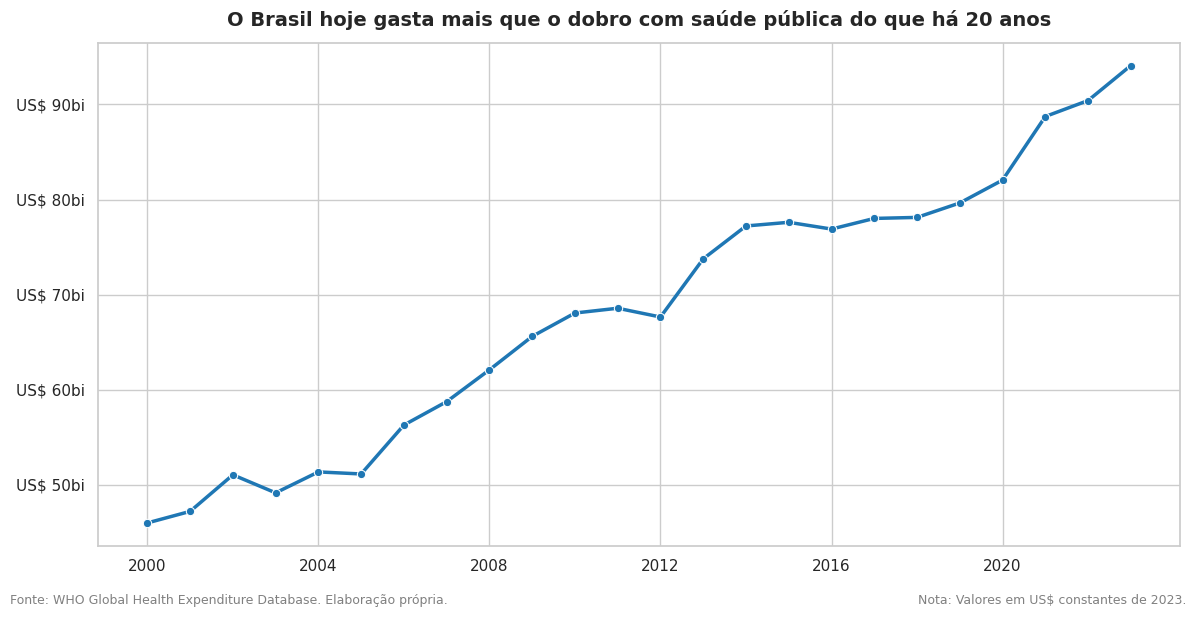

In [19]:
# Grafico 1: Gasto publico absoluto
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=df_hs_abs, x="year", y="value_bi",
    marker="o", linewidth=2.5, color=CORES["governo"],
)
ax.yaxis.set_major_formatter(FMT_BI)

plt.title(
    "O Brasil hoje gasta mais que o dobro com saúde pública do que há 20 anos",
    fontsize=14, weight="bold", pad=12,
)

plt.xticks(range(2000, 2024, 4))
plt.xlabel("")
plt.ylabel("")
adicionar_fonte()
plt.tight_layout()
plt.show()

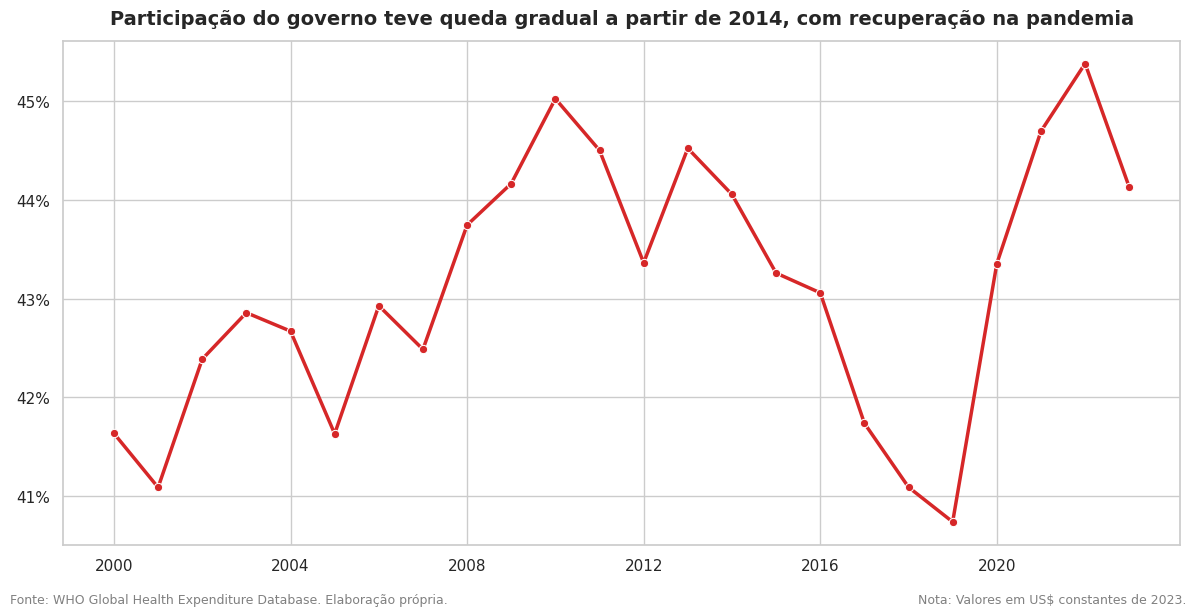

In [20]:
# Grafico 2: Participacao percentual do gasto publico
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=df_hs_pct, x="year", y="value",
    marker="o", linewidth=2.5, color=CORES["oop"],
)
ax.yaxis.set_major_formatter(FMT_PCT)

plt.title(
    "Participação do governo teve queda gradual a partir de 2014, com recuperação na pandemia",
    fontsize=14, weight="bold", pad=12,
)

plt.xticks(range(2000, 2024, 4))
plt.xlabel("")
plt.ylabel("")
adicionar_fonte()
plt.tight_layout()
plt.show()

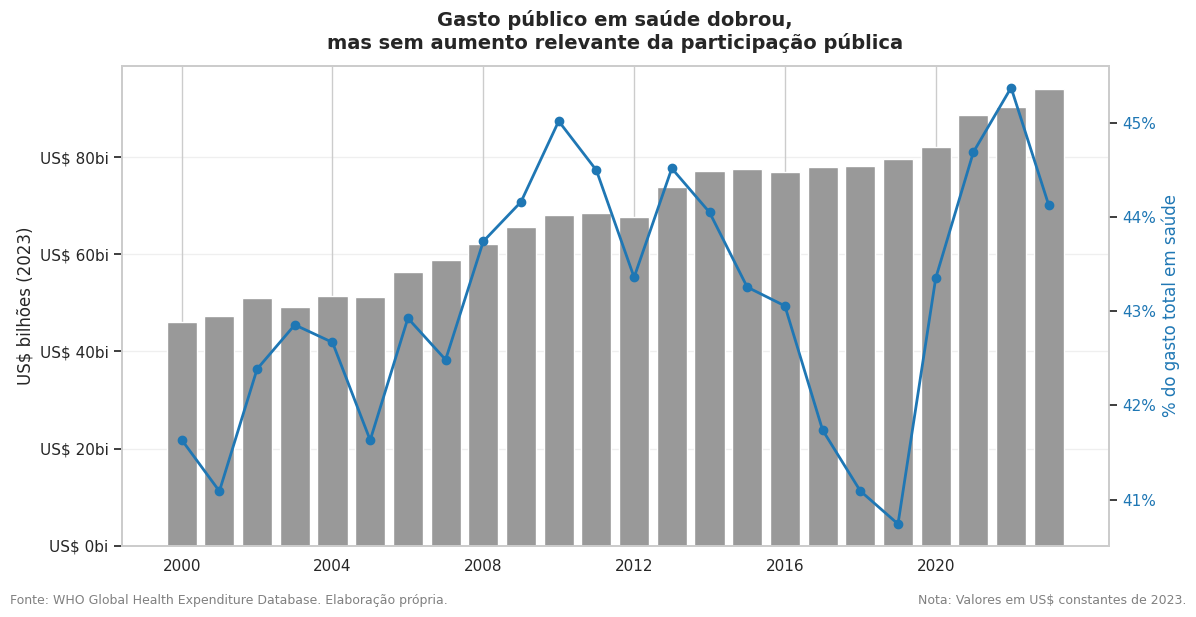

In [21]:
# Grafico 3: Panorama do Gasto Público em Saúde no Brasil nas últimas décadas
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_axisbelow(True)
ax1.grid(axis="y", alpha=0.3)

# Grafico de barras para o gasto absoluto
ax1.bar(df_hs_abs["year"], df_hs_abs["value_bi"], color=CORES["outro"], label="US$ bilhões (2023)")
ax1.yaxis.set_major_formatter(FMT_BI)
ax1.set_ylabel("US$ bilhões (2023)")
ax1.tick_params(axis='y')

# Criar um segundo eixo Y para a porcentagem
ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(df_hs_pct["year"], df_hs_pct["value"], color=CORES["governo"], marker="o", linewidth=2, label="% do gasto total em saúde")
ax2.yaxis.set_major_formatter(FMT_PCT)
ax2.set_ylabel("% do gasto total em saúde", color=CORES["governo"])
ax2.tick_params(axis='y', labelcolor=CORES["governo"])

plt.title(
    "Gasto público em saúde dobrou,\nmas sem aumento relevante da participação pública",
    fontsize=14, weight="bold", pad=12,
)

plt.xticks(range(2000, 2024, 4))
ax1.set_xlabel("")

adicionar_fonte()
plt.tight_layout()
plt.show()

#### Qual o perfil do gasto em saúde no Brasil e como ele evoluiu?

In [22]:
def preparar_pct_pivot(df, indicadores, renomear):
    pivot = (
        df[df["indicator_code"].isin(indicadores)]
        .pivot(index="year", columns="indicator_code", values="value")
        .reset_index()
        .rename(columns=renomear)
    )
    return pivot

renomear_hs = {"gghed_che": "Governo", "pvtd_che": "Privado", "ext_che": "Externo"}
df_hs_pct_pivot = preparar_pct_pivot(df_hs_brasil, INDICADORES_HS_PCT, renomear_hs)

df_hs_abs_pivot = preparar_pct_pivot(df_hs_brasil,
                                     INDICADORES_HS_ABS,
                                      {"che_usd2023": "total",
                                       "gghed_usd2023": "Governo",
                                       "pvtd_usd2023": "Privado",
                                       "ext_usd2023": "Externo"
                                       })

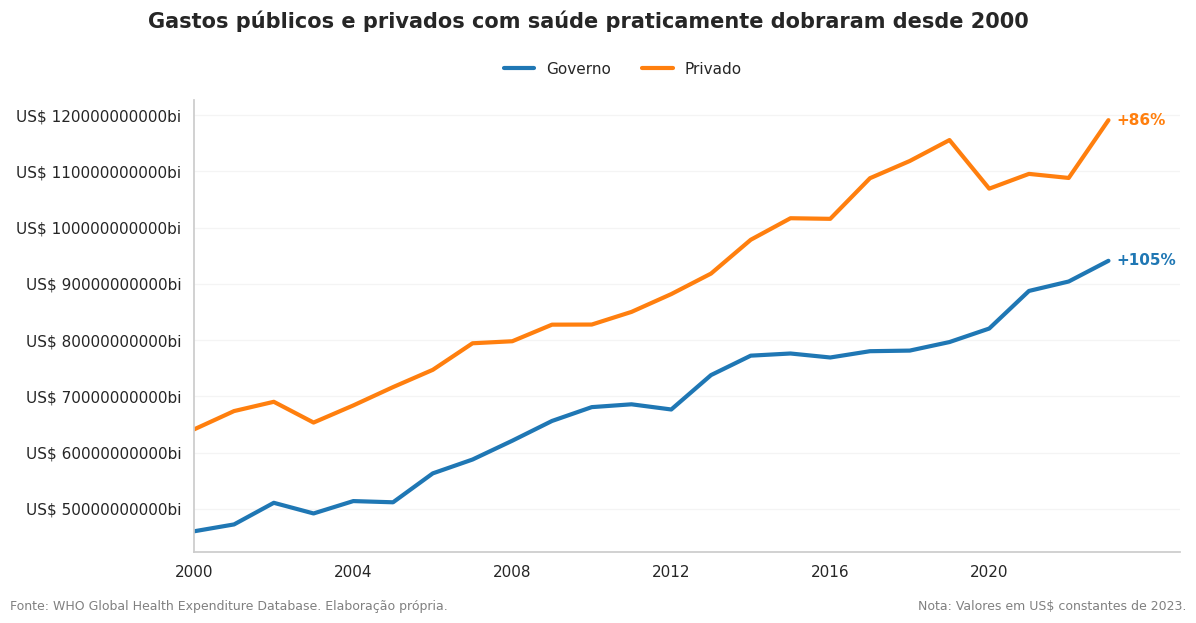

In [23]:
# Grafico 4: Evolucao absoluta das fontes de financiamento
fig, ax = plt.subplots(figsize=(12, 6))

# Dados
gov = df_hs_abs_pivot["Governo"]
priv = df_hs_abs_pivot["Privado"]
anos = df_hs_abs_pivot["year"]

# Linhas
ax.plot(
    anos,
    gov,
    linewidth=3,
    color=CORES["governo"],
    label="Governo",
)

ax.plot(
    anos,
    priv,
    linewidth=3,
    color=CORES["privado"],
    label="Privado",
)

# Formatter eixo Y
ax.yaxis.set_major_formatter(FMT_BI)

# Título
fig.suptitle(
    "Gastos públicos e privados com saúde praticamente dobraram desde 2000",
    fontsize=15,
    fontweight="bold",
    x=0.125,
    ha="left",
    y=0.98,
)

# Crescimento percentual
crescimento_gov = (gov.iloc[-1] / gov.iloc[0] - 1) * 100
crescimento_priv = (priv.iloc[-1] / priv.iloc[0] - 1) * 100

# Annotations simples
ax.text(
    2023.2,
    gov.iloc[-1],
    f"+{crescimento_gov:.0f}%",
    fontsize=11,
    fontweight="bold",
    color=CORES["governo"],
    va="center",
)

ax.text(
    2023.2,
    priv.iloc[-1],
    f"+{crescimento_priv:.0f}%",
    fontsize=11,
    fontweight="bold",
    color=CORES["privado"],
    va="center",
)

# Eixos
ax.set_xlim(2000, 2024.8)
ax.set_xticks(range(2000, 2024, 4))

ax.set_xlabel("")
ax.set_ylabel("")

# Grid
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legenda acima do gráfico
ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.3, 1.02),
    ncol=2,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

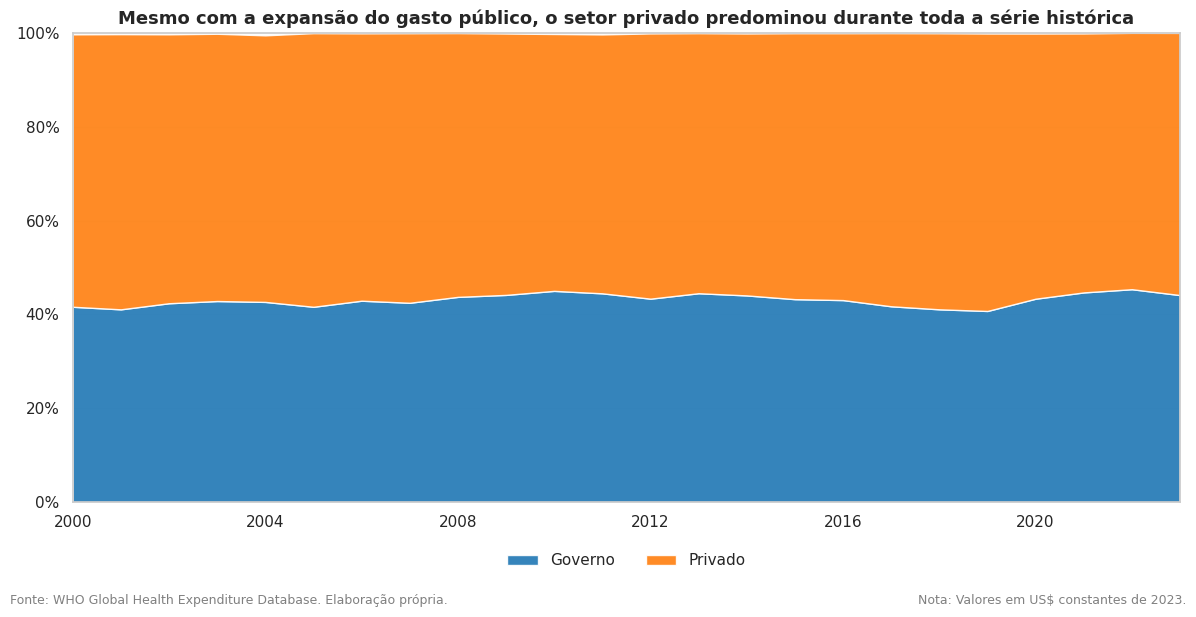

In [24]:
# Grafico 5: Perfil de financiamento ao longo dos anos (barras empilhadas)
fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    df_hs_pct_pivot["year"],
    df_hs_pct_pivot["Governo"],
    df_hs_pct_pivot["Privado"],
    # df_hs_pct_pivot["Externo"], # Financiamento Externo é praticamente irrelevante para a narrativa
    labels=["Governo",
            "Privado",
            # "Externo"
            ],
    colors=[
        CORES["governo"],
        CORES["privado"],
        # CORES["externo"],
    ],
    alpha=0.9,
)

plt.title(
    "Mesmo com a expansão do gasto público, o setor privado predominou durante toda a série histórica",
    fontsize=13,
    weight="bold",
)

ax.set_xlim(2000, 2023)
ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(FMT_PCT)

plt.xticks(range(2000, 2024, 4))

plt.xlabel("")
plt.ylabel("")

ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

plt.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

#### Qual o perfil dos países do BRICS?
O BRICS é um agrupamento de 5 economias emergentes (Brasil, Rússia, Índia, China e África do Sul) que se expandiu a partir de 2024-2025, passando a incluir outros 6 membros: Arábia Saudita, Egito, Emirados Árabes Unidos, Etiópia, Irã e Indonésia.

O bloco representa cerca de 40% do PIB global e quase 50% da população mundial

* [Fonte](https://brics.br/pt-br/sobre-o-brics/perguntas-frequentes-sobre-o-brics?activeAccordion=ac0488e2-dd49-4b08-8856-ba8e27eda851)

In [25]:
df_hs_brics_abs = (
    df_hs_brics[df_hs_brics["indicator_code"] == "che_usd2023"]
    .pipe(traduzir_paises)
    .pivot(index="year", columns="country_name", values="value")
    .reset_index()
    .pipe(para_bilhoes, colunas=["Brasil", "Rússia", "Índia", "China", "África do Sul"])
)

df_hs_brics_abs_plot = df_hs_brics_abs.melt(
    id_vars="year", var_name="Pais", value_name="total"
)

palette_brics = {p: CORES.get(p, "#cccccc") for p in df_hs_brics_abs_plot["Pais"].unique()}

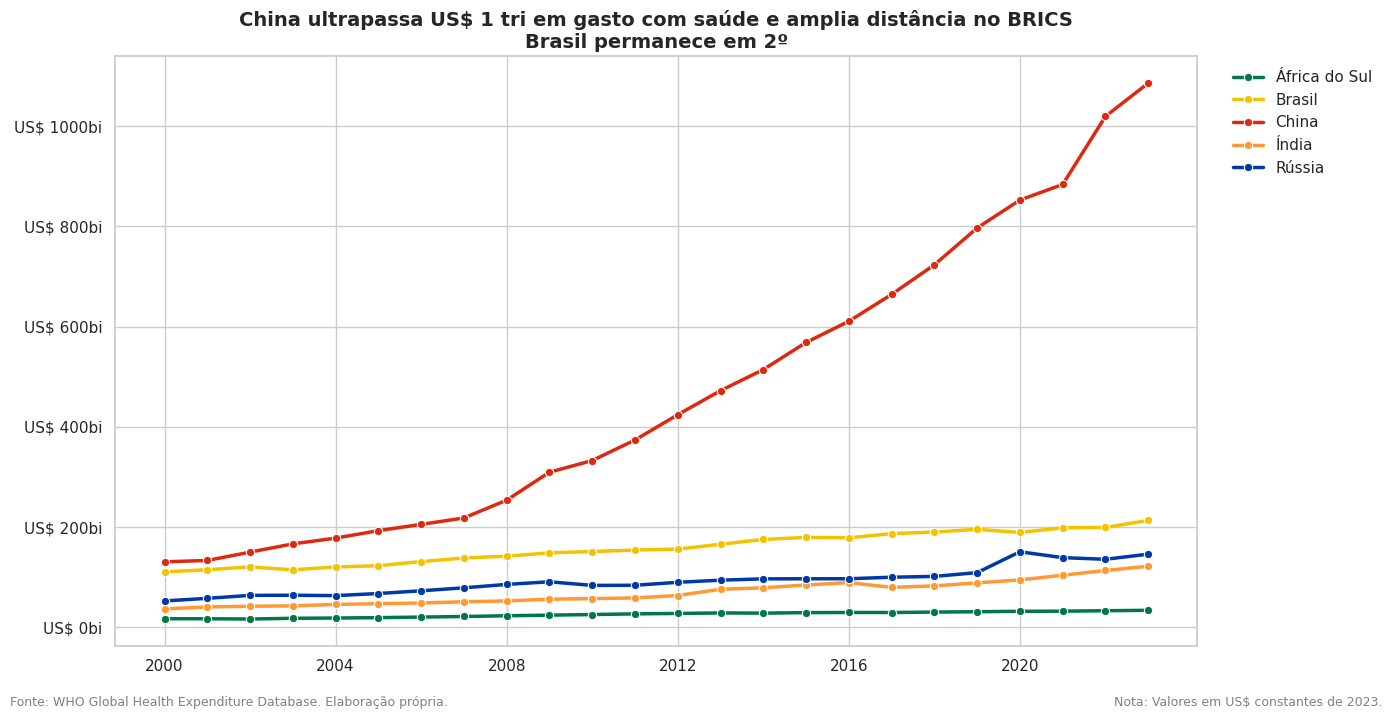

In [26]:
# Grafico 6: Evolucao do gasto total no BRICS
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=df_hs_brics_abs_plot, x="year", y="total",
    hue="Pais",
    hue_order=["África do Sul", "Brasil", "China", "Índia", "Rússia"],
    marker="o", linewidth=2.5, palette=palette_brics,
)
ax.yaxis.set_major_formatter(FMT_BI)

plt.title(
    "China ultrapassa US$ 1 tri em gasto com saúde e amplia distância no BRICS\nBrasil permanece em 2º",
    fontsize=14, weight="bold",
)

plt.xticks(range(2000, 2024, 4))

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

adicionar_fonte()
plt.tight_layout()
plt.show()

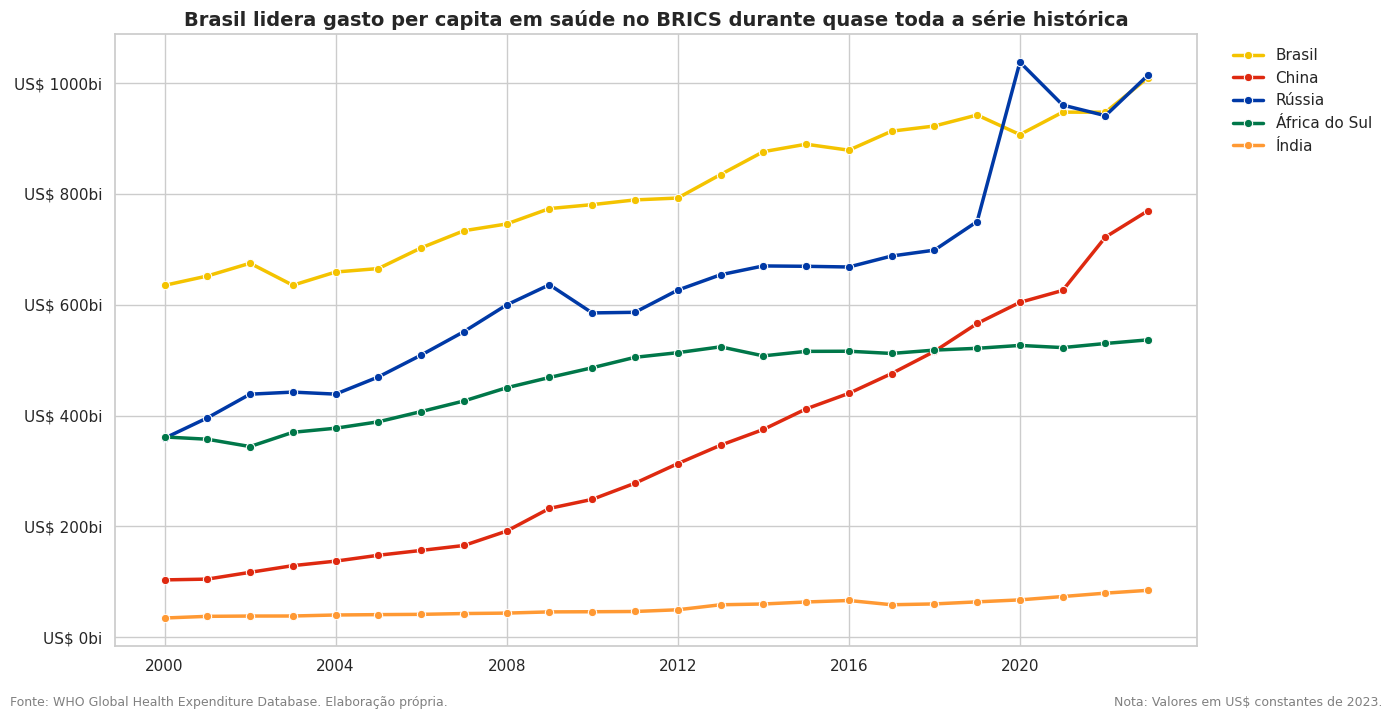

In [27]:
# Grafico 7: Evolucao do gasto per capita em paises do BRICS
df_pop = traduzir_paises(df_pop, coluna='Country')
df_pop['Year'] = df_pop['Year'].astype('int64')

df_hs_brics_pc = df_hs_brics_abs_plot.merge(
    df_pop[["Country", "Year", "SP.POP.TOTL"]],
    left_on=["Pais", "year"],
    right_on=["Country", "Year"],
    how="left"
)

df_hs_brics_pc.drop(["Country", "Year"], axis=1, inplace=True)
df_hs_brics_pc.rename(columns={"SP.POP.TOTL": "População"}, inplace=True)

df_hs_brics_pc["gasto_pc"] = (df_hs_brics_pc["total"] * 1e9) / df_hs_brics_pc["População"]


plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=df_hs_brics_pc, x="year", y="gasto_pc",
    hue="Pais", marker="o", linewidth=2.5,
    palette=palette_brics
)
ax.yaxis.set_major_formatter(FMT_BI)

plt.title(
    "Brasil lidera gasto per capita em saúde no BRICS durante quase toda a série histórica",
    fontsize=14, weight="bold",
)

plt.xticks(range(2000, 2024, 4))

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

adicionar_fonte()

plt.tight_layout()
plt.show()

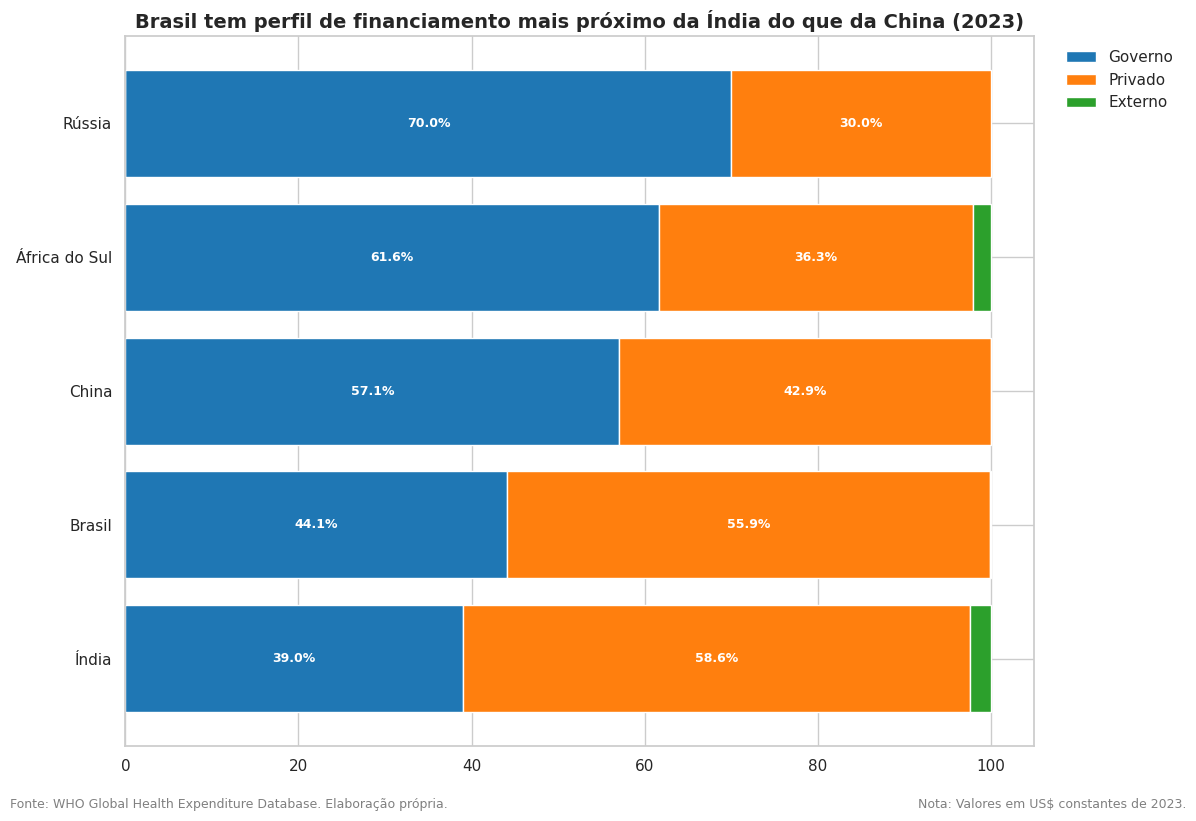

In [28]:
# Grafico 8: Perfil de financiamento do BRICS em 2023
df_hs_brics_pct_23 = (
    df_hs_brics[
        (df_hs_brics["year"] == 2023) &
        (df_hs_brics["indicator_code"].isin(INDICADORES_HS_PCT))
    ]
    .pipe(traduzir_paises)
    .pivot(index="country_name", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns=renomear_hs)
    .sort_values("Governo", ascending=False)
)

ax = df_hs_brics_pct_23.set_index("country_name")[["Governo", "Privado", "Externo"]].plot(
    kind="barh", stacked=True,
    figsize=(12, 8), color=CORES_HS_INDIC, width=0.8,
)
adicionar_rotulos_internos(ax, threshold=4)
ax.invert_yaxis()

plt.title(
    "Brasil tem perfil de financiamento mais próximo da Índia do que da China (2023)",
    fontsize=14, weight="bold",
)

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

adicionar_fonte()

plt.tight_layout()
plt.show()

#### Como está situado o Brasil frente a outros sistemas universais?

Vários países possuem sistemas de saúde públicos, universais e gratuitos semelhantes ao SUS brasileiro, garantindo atendimento a residentes por meio de impostos. Exemplos notáveis incluem Reino Unido (NHS), Canadá, Austrália (Medicare), França, Espanha, Portugal, Suécia e Uruguai (SNS), cada um com suas peculiaridades de financiamento e cobertura.

* [Fonte](https://www.simers.org.br/noticia/conheca-o-sus-de-outros-cinco-paises)

In [29]:
df_hs_univ_abs = (
    df_hs_universal[df_hs_universal["indicator_code"] == "che_usd2023"]
    .pipe(traduzir_paises)
    .pivot(index="year", columns="country_name", values="value")
    .reset_index()
)
cols_univ = [c for c in df_hs_univ_abs.columns if c != "year"]
df_hs_univ_abs = para_bilhoes(df_hs_univ_abs, cols_univ)

df_hs_univ_abs_plot = df_hs_univ_abs.melt(
    id_vars="year", var_name="Pais", value_name="total"
)

palette_univ = {
    "Brasil":      CORES["Brasil_univ"],
    "França":      CORES["França"],
    "Espanha":     CORES["Espanha"],
    "Reino Unido": CORES["Reino Unido"],
    "Canadá":      CORES["Canadá"],
    "Uruguai":     CORES["Uruguai"],
    "Portugal":    CORES["Portugal"],
    "Suécia":      CORES["Suécia"],
    "Austrália":   CORES["Austrália"],
}

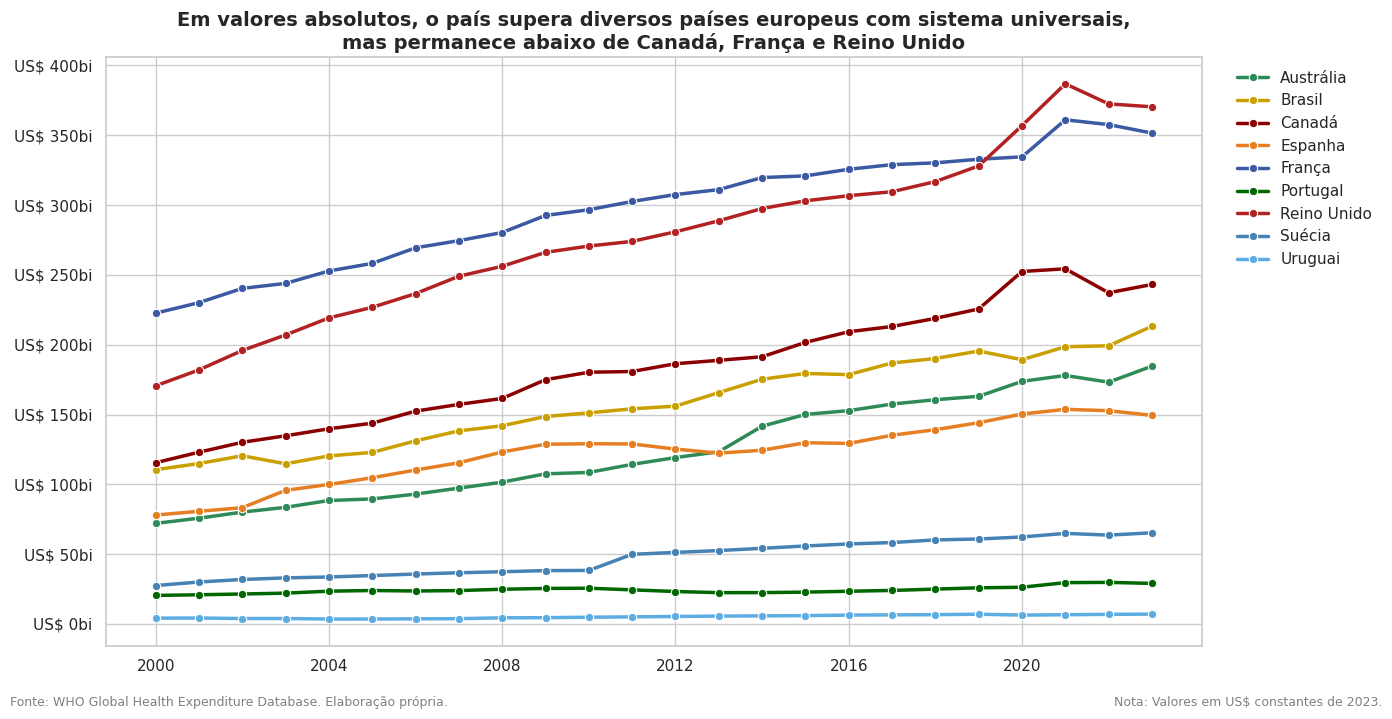

In [30]:
# Grafico 9: Evolucao do gasto total em paises com sistema universal
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=df_hs_univ_abs_plot, x="year", y="total",
    hue="Pais", marker="o", linewidth=2.5,
    palette={p: palette_univ.get(p, "#cccccc") for p in df_hs_univ_abs_plot["Pais"].unique()},
)
ax.yaxis.set_major_formatter(FMT_BI)

plt.title(
    "Em valores absolutos, o país supera diversos países europeus com sistema universais,\nmas permanece abaixo de Canadá, França e Reino Unido",
    fontsize=14, weight="bold",
)

plt.xticks(range(2000, 2024, 4))

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

adicionar_fonte()

plt.tight_layout()
plt.show()

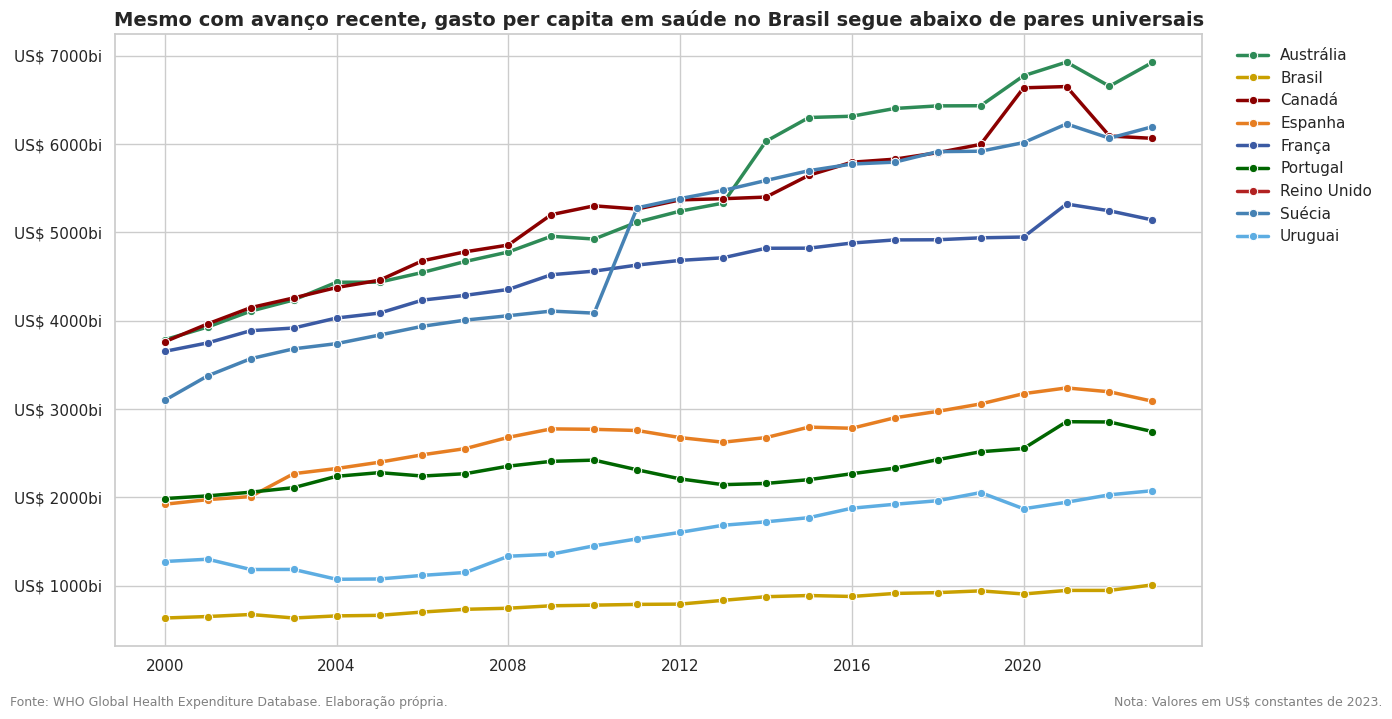

In [31]:
# Grafico 10: Evolucao do gasto per capita em paises com sistema universal
df_pop = traduzir_paises(df_pop, coluna='Country')
df_pop['Year'] = df_pop['Year'].astype('int64')

df_hs_univ_pc = df_hs_univ_abs_plot.merge(
    df_pop[["Country", "Year", "SP.POP.TOTL"]],
    left_on=["Pais", "year"],
    right_on=["Country", "Year"],
    how="left"
)

df_hs_univ_pc.drop(["Country", "Year"], axis=1, inplace=True)
df_hs_univ_pc.rename(columns={"SP.POP.TOTL": "População"}, inplace=True)

df_hs_univ_pc["gasto_pc"] = (df_hs_univ_pc["total"] * 1e9) / df_hs_univ_pc["População"]


plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=df_hs_univ_pc, x="year", y="gasto_pc",
    hue="Pais", marker="o", linewidth=2.5,
    palette={p: palette_univ.get(p, "#cccccc") for p in df_hs_univ_abs_plot["Pais"].unique()},
)

ax.yaxis.set_major_formatter(FMT_BI)

plt.title(
    "Mesmo com avanço recente, gasto per capita em saúde no Brasil segue abaixo de pares universais",
    fontsize=14, weight="bold",
)

plt.xticks(range(2000, 2024, 4))

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

adicionar_fonte()

plt.tight_layout()
plt.show()

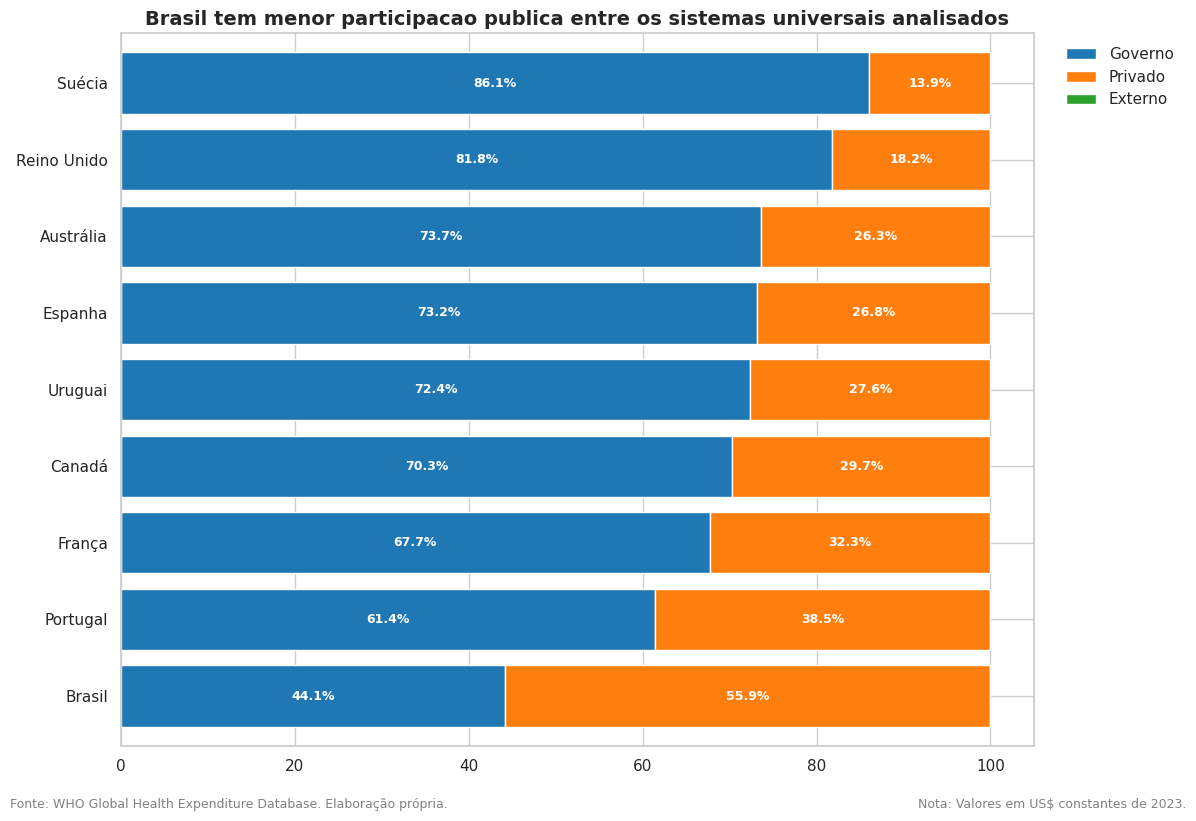

In [32]:
# Grafico 11: Perfil de financiamento dos sistemas universais em 2023
df_hs_univ_pct_23 = (
    df_hs_universal[
        (df_hs_universal["year"] == 2023) &
        (df_hs_universal["indicator_code"].isin(INDICADORES_HS_PCT))
    ]
    .pipe(traduzir_paises)
    .pivot(index="country_name", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns=renomear_hs)
    .sort_values("Governo", ascending=False)
)

ax = df_hs_univ_pct_23.set_index("country_name")[["Governo", "Privado", "Externo"]].plot(
    kind="barh", stacked=True,
    figsize=(12, 8), color=CORES_HS_INDIC, width=0.8,
)
adicionar_rotulos_internos(ax, threshold=4)
ax.invert_yaxis()

plt.title(
    "Brasil tem menor participacao publica entre os sistemas universais analisados",
    fontsize=14, weight="bold",
)

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

adicionar_fonte()

plt.tight_layout()
plt.show()

### Esquemas
Dicionario de indicadores (equivalentes brasileiros):
- **HF1**: SUS + RPPS — esquemas publicos obrigatorios
- **HF2**: Planos de Saude — seguros voluntarios privados
- **HF3**: Desembolso direto (OOP) — pagamento sem intermediario
- **HF4**: Ajuda externa — praticamente irrelevante no Brasil
- **HFNEC**: Gastos nao classificados

Hipoteses:
- HF1 alto + HF3 alto = sistema publico existe, mas nao resolve
- HF1 alto + HF3 baixo = sistema publico funciona de fato
- HF1 baixo + HF2 alto = sistema predominantemente privado (modelo EUA)

#### Preparação dos dados

In [33]:
INDICADORES_FS_PCT = ["hf1_che", "hf2_che", "hf3_che", "hf4_che", "hfnec_che"]
INDICADORES_FS_ABS = ["hf1_usd2023", "hf2_usd2023", "hf3_usd2023", "hf4_usd2023", "hfnec_usd2023"]

RENOMEAR_FS = {
    "hf1_che": "SUS + RPPS",
    "hf2_che": "Planos de Saude",
    "hf3_che": "Desembolso direto",
    "hf4_che": "Ajuda Externa",
    "hfnec_che": "Nao Identificado",
    "hf1_usd2023": "SUS + RPPS",
    "hf2_usd2023": "Planos de Saude",
    "hf3_usd2023": "Desembolso direto",
    "hf4_usd2023": "Ajuda Externa",
    "hfnec_usd2023": "Nao Identificado",
}

def preparar_fs(lista_paises=None):
    mask = financing_schemes["indicator_code"].isin(INDICADORES_FS_PCT + INDICADORES_FS_ABS)
    if lista_paises:
        mask &= financing_schemes["country_name"].isin(lista_paises)
    return financing_schemes[mask].copy()

df_fs_brasil    = preparar_fs(["Brazil"])
df_fs_brics     = preparar_fs(PAISES_BRICS)
df_fs_universal = preparar_fs(PAISES_UNIVERSAL)

#### Qual a proporção entre público, privado e desembolso direto no Brasil?

- Entre 2000 e 2023, a participação do SUS + RPPS no financiamento da saúde no Brasil subiu de 41,6% para 44,1%. Ainda assim, o financiamento público permanece abaixo da metade do gasto total em saúde.
Outro ponto importante é que até 2015, o desembolso direto das famílias superava os gastos intermediados por planos de saúde.
- Hoje o gasto privado representam parcela maior do financiamento, mas as famílias ainda bancam diretamente cerca de 25% de todo o gasto em saúde no país. Na prática, isso significa que uma parte relevante do acesso à saúde continua dependendo da capacidade de pagamento das famílias — mesmo em um sistema universal.

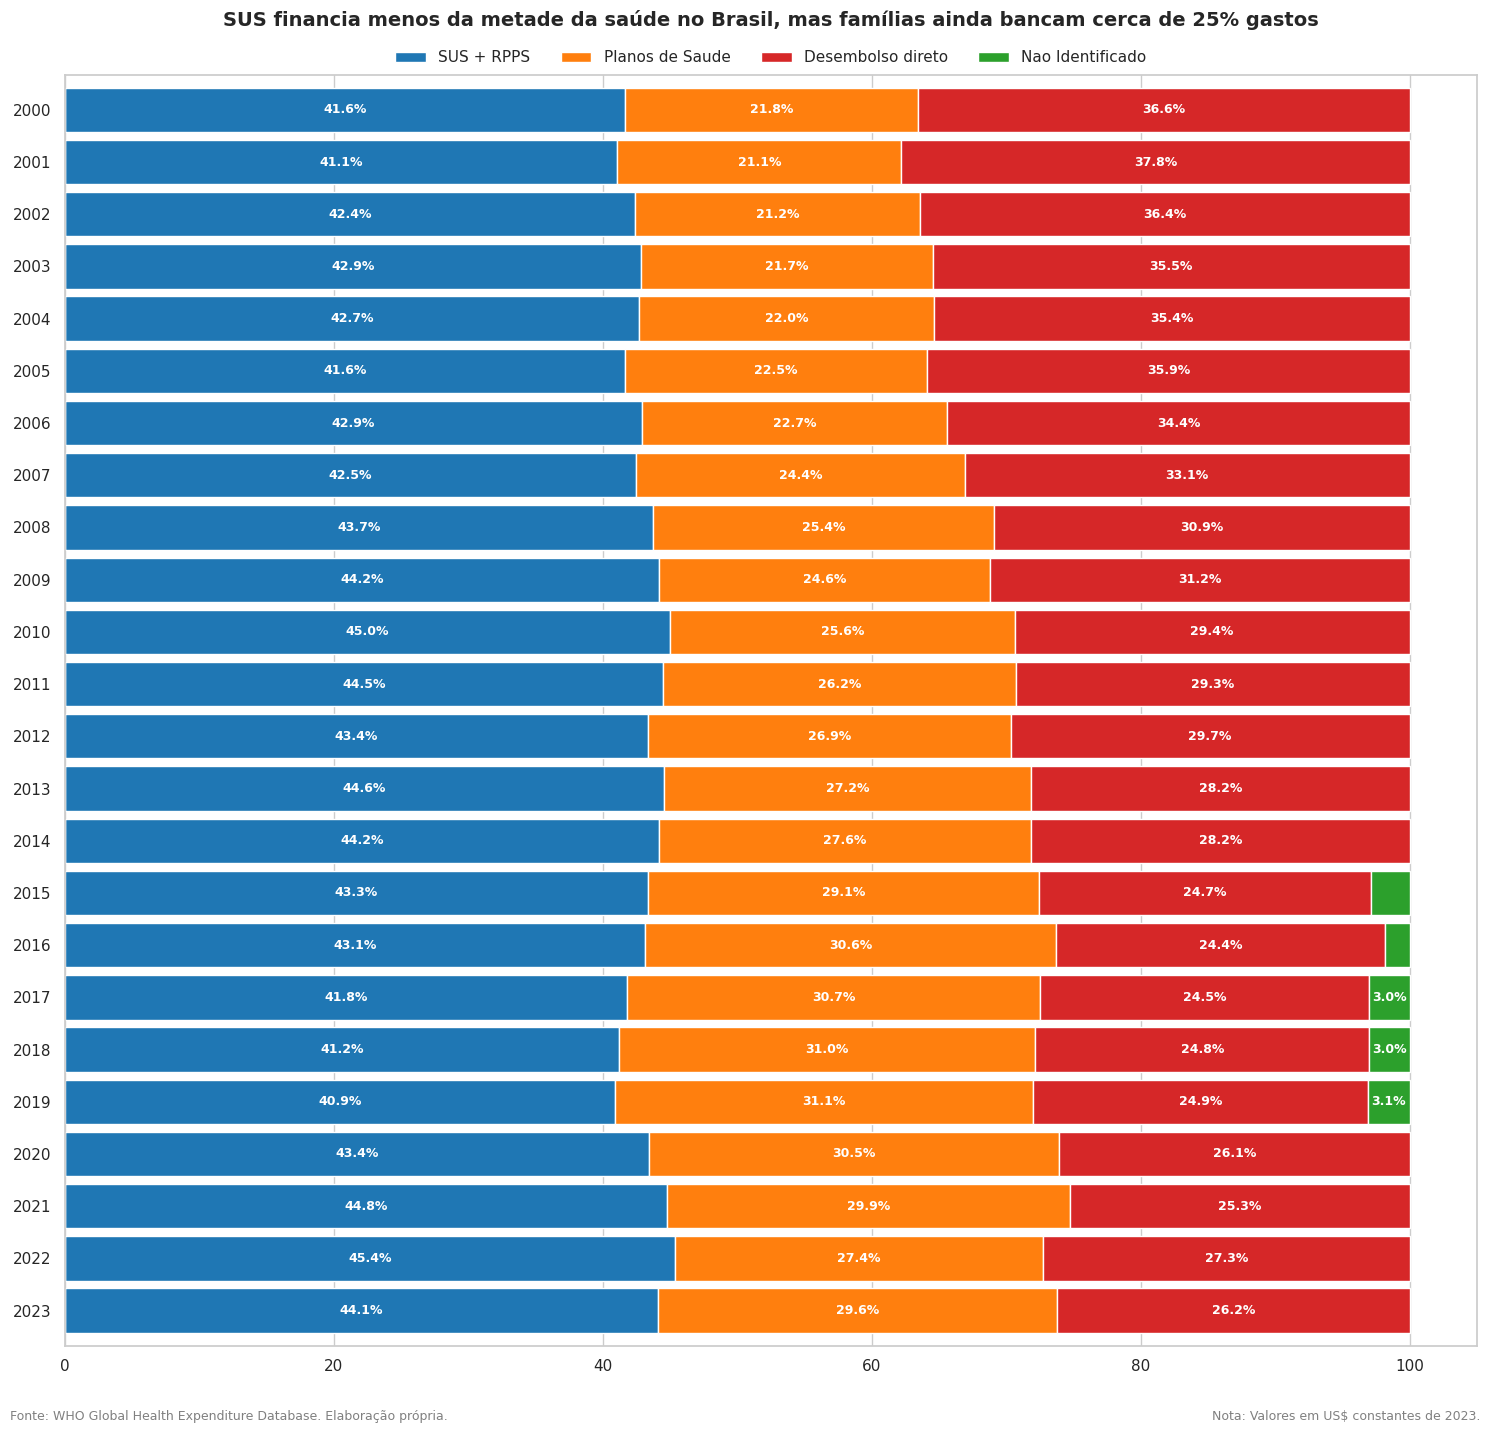

In [34]:
# Grafico 12: Perfil do gasto em saúde no Brasil
df_fs_pct_pivot = (
    df_fs_brasil[df_fs_brasil["indicator_code"].isin(INDICADORES_FS_PCT)]
    .pivot(index="year", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns={**RENOMEAR_FS, "year": "Ano"})
)

df_fs_pct_pivot.drop(columns=["Ajuda Externa"], inplace=True)

ax = df_fs_pct_pivot.set_index("Ano").plot(
    kind="barh", stacked=True,
    figsize=(15, 14), color=CORES_FS_INDIC, width=0.85,
)
adicionar_rotulos_internos(ax, threshold=3)
ax.grid(axis="y", visible=False)
ax.invert_yaxis()

plt.title(
    "SUS financia menos da metade da saúde no Brasil, mas famílias ainda bancam cerca de 25% gastos",
    fontsize=14, weight="bold", pad=35,
)

plt.xlabel("")
plt.ylabel("")

plt.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

#### O Desembolso Direto brasileiro diminuiu ao longo do tempo, ou as famílias ainda pagam muito do próprio bolso?
- O financiamento da saúde no Brasil cresceu de forma significativa desde 2000, liderado pelos planos de saúde, enquanto o SUS dobrou de escala e o desembolso direto perdeu dinamismo relativo.

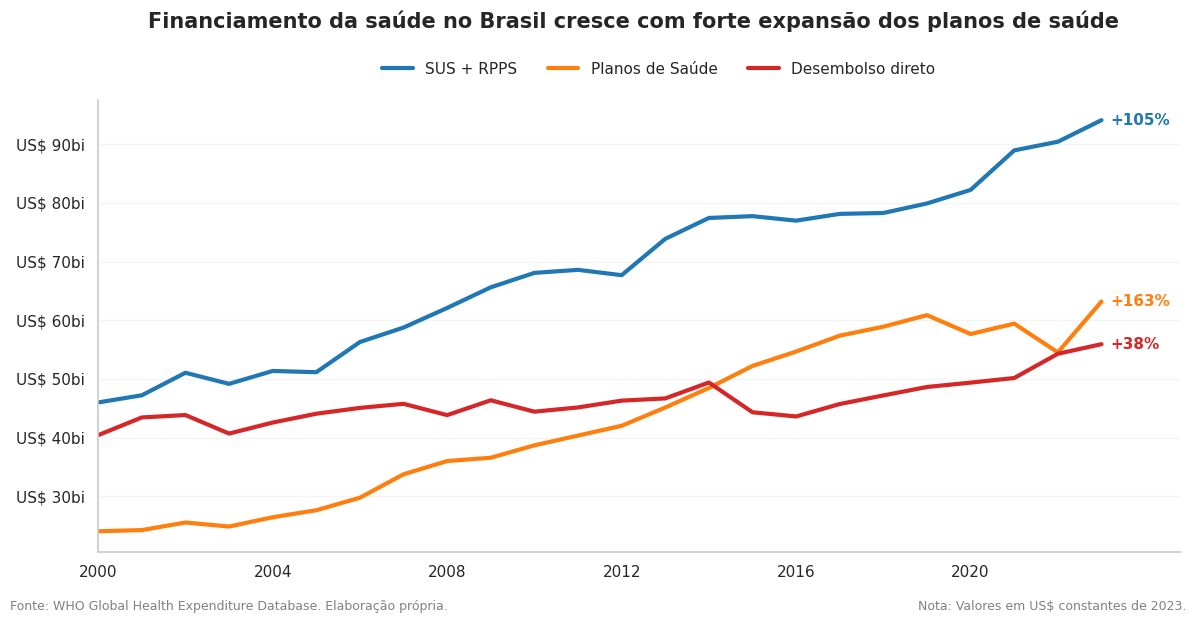

In [35]:
# Grafico 13: Crescimento dos indicadores
df_fs_abs_pivot = (
    df_fs_brasil[df_fs_brasil["indicator_code"].isin(INDICADORES_FS_ABS)]
    .pivot(index="year", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns={**RENOMEAR_FS, "year": "Ano"})
)

cols_bi = ["SUS + RPPS", "Planos de Saude", "Desembolso direto"]
df_fs_abs_pivot = para_bilhoes(df_fs_abs_pivot, cols_bi)

df_fs_abs_plot = df_fs_abs_pivot.melt(
    id_vars="Ano", value_vars=cols_bi,
    var_name="Componente", value_name="Valor",
)

df_fs_abs_plot = df_fs_abs_plot.pivot(
    index="Ano",
    columns="Componente",
    values="Valor"
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

anos = df_fs_abs_plot["Ano"]
sus = df_fs_abs_plot["SUS + RPPS"]
planos = df_fs_abs_plot["Planos de Saude"]
oop = df_fs_abs_plot["Desembolso direto"]

# Linhas
ax.plot(
    anos,
    sus,
    linewidth=3,
    color=CORES["governo"],
    label="SUS + RPPS",
)

ax.plot(
    anos,
    planos,
    linewidth=3,
    color=CORES["privado"],
    label="Planos de Saúde",
)

ax.plot(
    anos,
    oop,
    linewidth=3,
    color=CORES["oop"],
    label="Desembolso direto",
)

# Título
fig.suptitle(
    "Financiamento da saúde no Brasil cresce com forte expansão dos planos de saúde",
    fontsize=15,
    fontweight="bold",
    x=0.125,
    ha="left",
    y=0.98,
)

# Crescimento (%)
cres_sus = (sus.iloc[-1] / sus.iloc[0] - 1) * 100
cres_planos = (planos.iloc[-1] / planos.iloc[0] - 1) * 100
cres_oop = (oop.iloc[-1] / oop.iloc[0] - 1) * 100

# Anotações finais
ax.text(
    2023.2,
    sus.iloc[-1],
    f"+{cres_sus:.0f}%",
    fontsize=11,
    fontweight="bold",
    color=CORES["governo"],
    va="center",
)

ax.text(
    2023.2,
    planos.iloc[-1],
    f"+{cres_planos:.0f}%",
    fontsize=11,
    fontweight="bold",
    color=CORES["privado"],
    va="center",
)

ax.text(
    2023.2,
    oop.iloc[-1],
    f"+{cres_oop:.0f}%",
    fontsize=11,
    fontweight="bold",
    color=CORES["oop"],
    va="center",
)

# Eixos
ax.yaxis.set_major_formatter(FMT_BI)
ax.set_xlim(2000, 2024.8)
ax.set_xticks(range(2000, 2024, 4))

ax.set_xlabel("")
ax.set_ylabel("")

# Grid
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legenda
ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.25, 1.02),
    ncol=3,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

#### Como o Brasil se compara ao BRICS no Desembolso Direto?

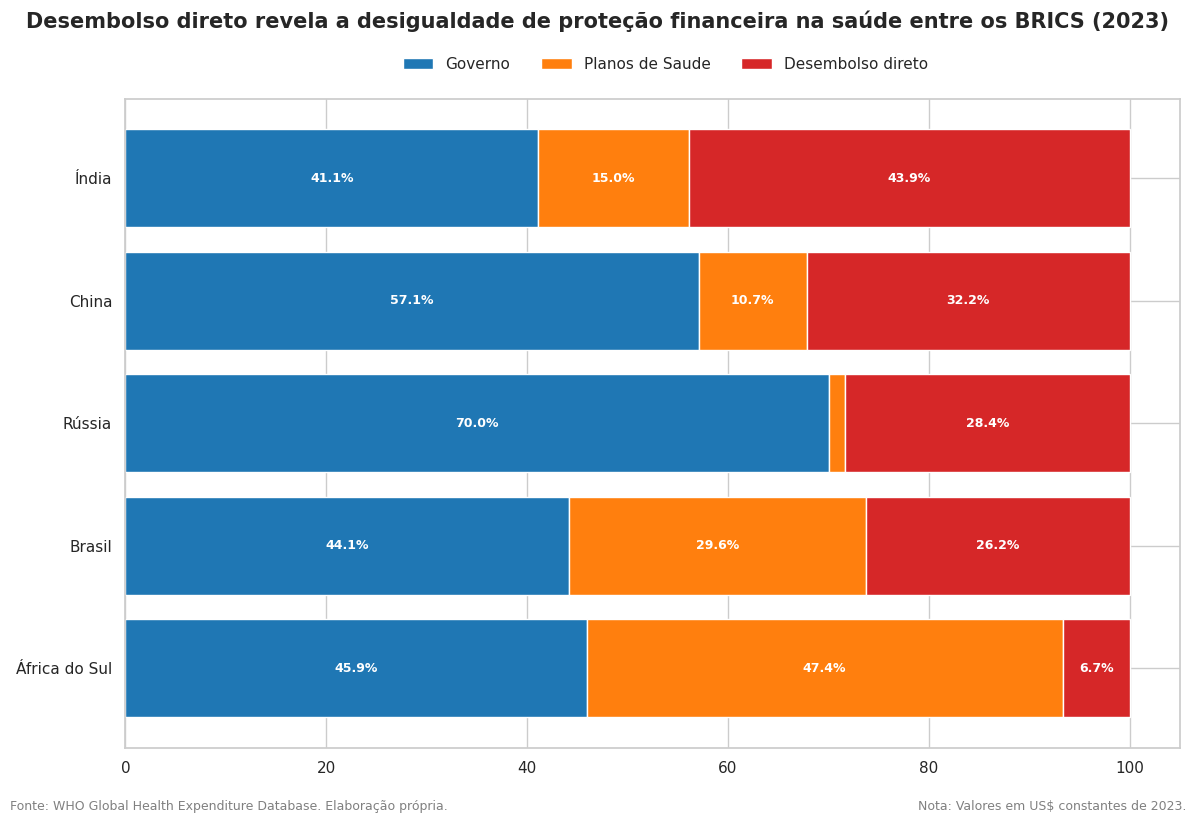

In [36]:
# Grafico 14: Desembolso direto no BRICS
df_fs_brics_pct_23 = (
    df_fs_brics[
        (df_fs_brics["year"] == 2023) &
        (df_fs_brics["indicator_code"].isin(INDICADORES_FS_PCT))
    ]
    .pipe(traduzir_paises)
    .pivot(index="country_name", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns=RENOMEAR_FS)
    .rename(columns={"SUS + RPPS": "Governo"})
    .sort_values("Desembolso direto", ascending=False)
)

colunas_fs = ["Governo", "Planos de Saude", "Desembolso direto"]

ax = df_fs_brics_pct_23.set_index("country_name")[colunas_fs].plot(
    kind="barh", stacked=True,
    figsize=(12, 8), color=CORES_FS_INDIC, width=0.8,
)

adicionar_rotulos_internos(ax, threshold=4)
ax.invert_yaxis()

plt.suptitle(
    "Desembolso direto revela a desigualdade de proteção financeira na saúde entre os BRICS (2023)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("")

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.25, 1.02),
    ncol=3,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

#### Como o Brasil se compara a outros países com sistemas universais no Desembolso Direto?
- Brasil tem sistema universal, mas nível de desembolso direto semelhante a países com proteção intermediária — não aos sistemas universais mais maduros

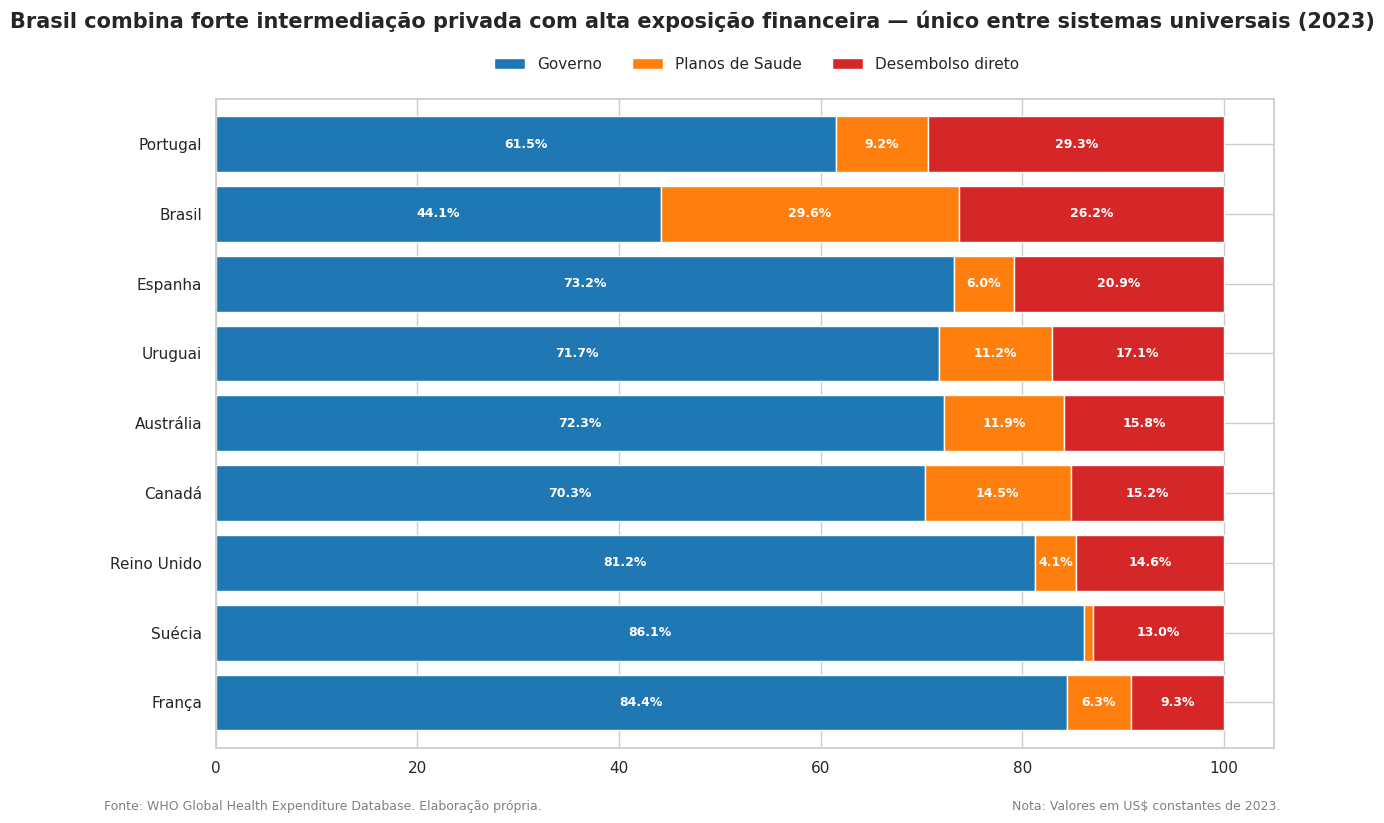

In [37]:
# Grafico 15: Desembolso Direto em sistemas universais
df_fs_univ_pct_23 = (
    df_fs_universal[
        (df_fs_universal["year"] == 2023) &
        (df_fs_universal["indicator_code"].isin(INDICADORES_FS_PCT))
    ]
    .pipe(traduzir_paises)
    .pivot(index="country_name", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns=RENOMEAR_FS)
    .rename(columns={"SUS + RPPS": "Governo"})
    .sort_values("Desembolso direto", ascending=False)
)

colunas_fs = ["Governo", "Planos de Saude", "Desembolso direto"]

ax = df_fs_univ_pct_23.set_index("country_name")[colunas_fs].plot(
    kind="barh", stacked=True,
    figsize=(12, 8), color=CORES_FS_INDIC, width=0.8,
)

adicionar_rotulos_internos(ax, threshold=4)
ax.invert_yaxis()

plt.suptitle(
    "Brasil combina forte intermediação privada com alta exposição financeira — único entre sistemas universais (2023)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("")

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.25, 1.02),
    ncol=3,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

### Destino
Dicionario de indicadores (equivalentes brasileiros):
- **HC1**: Assistencia curativa — consultas, cirurgias, internacoes, pronto-socorro
- **HC2**: Reabilitacao — fisioterapia, recuperacao pos-cirurgica, CAPS
- **HC3**: Cuidados de longa duracao — cuidados paliativos, ILPI (asilos), home care
- **HC4**: Servicos auxiliares — exames laboratoriais, imagem, anatomia patologica
- **HC5**: Produtos medicos — medicamentos, proteses, orteses, cadeiras de rodas
- **HC6**: Prevencao e promocao — vacinas, ESF, vigilancia epidemiologica, campanhas
- **HC7**: Governanca e administracao — Ministerio da Saude, ANS, ANVISA, gestao hospitalar
- **HC9**: Outros

Eixo analitico central:
- REATIVO (HC1) vs PROATIVO (HC6)
  - RECUPERAR/TRATAR (HC2 - HC5)
- Quanto o Brasil gasta em HC1 para cada R$1 gasto em HC6?

#### Preparação dos dados

In [38]:
INDICADORES_SP_PCT = ["hc1_che","hc2_che","hc3_che","hc4_che","hc5_che","hc6_che","hc7_che","hc9_che"]
INDICADORES_SP_ABS = ["hc1_usd2023","hc2_usd2023","hc3_usd2023","hc4_usd2023",
                      "hc5_usd2023","hc6_usd2023","hc7_usd2023","hc9_usd2023"]

RENOMEAR_SP_PT = {
    "hc1_che": "Assistencia curativa",
    "hc2_che": "Reabilitacao",
    "hc3_che": "Cuidados de longa duracao",
    "hc4_che": "Servicos auxiliares",
    "hc5_che": "Produtos medicos",
    "hc6_che": "Prevencao e promocao",
    "hc7_che": "Governanca e administracao",
    "hc9_che": "Outros",
    "hc1_usd2023": "Assistencia curativa",
    "hc2_usd2023": "Reabilitacao",
    "hc3_usd2023": "Cuidados de longa duracao",
    "hc4_usd2023": "Servicos auxiliares",
    "hc5_usd2023": "Produtos medicos",
    "hc6_usd2023": "Prevencao e promocao",
    "hc7_usd2023": "Governanca e administracao",
    "hc9_usd2023": "Outros",
}

MAPA_GRUPAMENTO = {
    "hc1": "Reativo",
    "hc2": "Recuperativo/Suporte",
    "hc3": "Recuperativo/Suporte",
    "hc4": "Recuperativo/Suporte",
    "hc5": "Recuperativo/Suporte",
    "hc6": "Preventivo/Proativo",
    "hc7": "Outros",
    "hc9": "Outros",
}

def adicionar_grupamento(df):
    df = df.copy()
    df["grupo"] = (
        df["indicator_code"]
        .str.extract(r"^(hc\d+)", expand=False)
        .map(MAPA_GRUPAMENTO)
    )
    return df

def preparar_sp(lista_paises=None):
    mask = spending_purpose["indicator_code"].isin(INDICADORES_SP_PCT + INDICADORES_SP_ABS)
    if lista_paises:
        mask &= spending_purpose["country_name"].isin(lista_paises)
    return spending_purpose[mask].copy().pipe(adicionar_grupamento)

df_sp_brasil    = preparar_sp(["Brazil"])
df_sp_brics     = preparar_sp(PAISES_BRICS)
df_sp_universal = preparar_sp(PAISES_UNIVERSAL)


#### O Brasil investe mais em cuidado curativo ou preventivo?

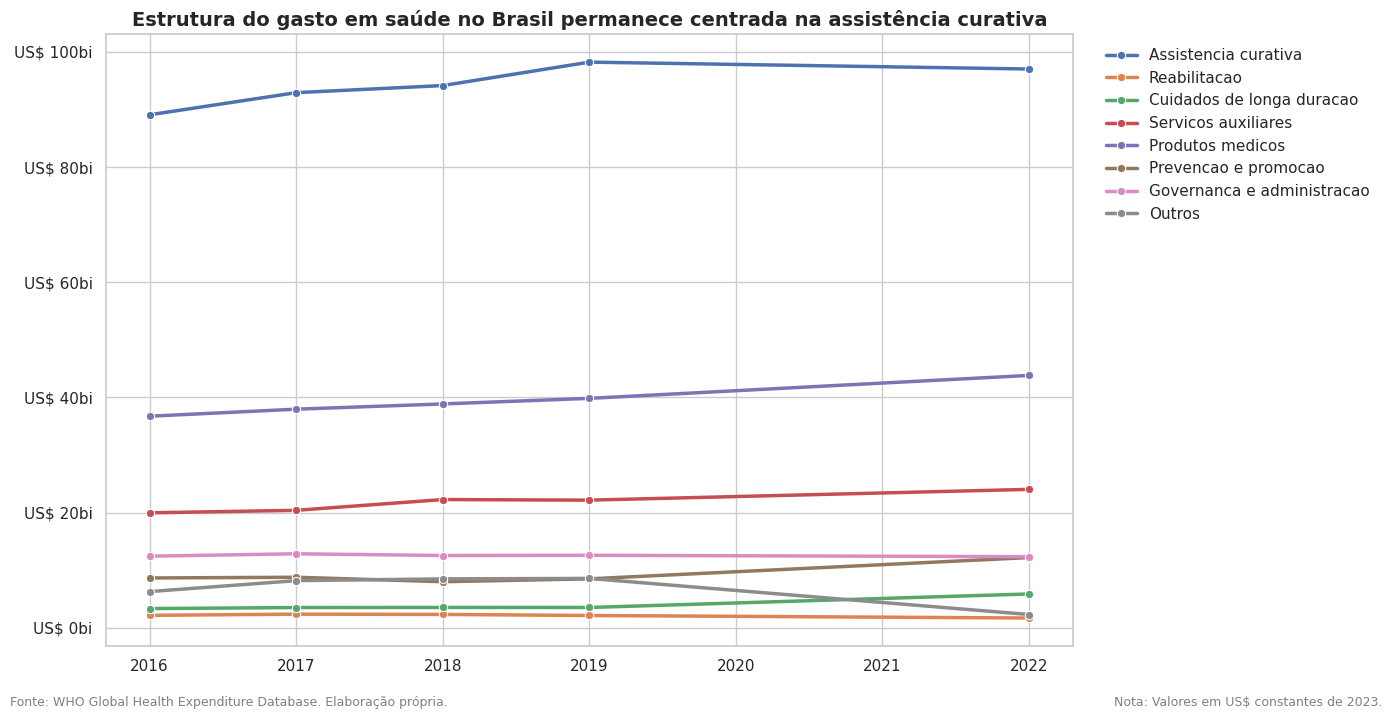

In [39]:
# Grafico 16: Evolução dos gasto por componentes
df_sp_abs_pivot = (
    df_sp_brasil[df_sp_brasil["indicator_code"].isin(INDICADORES_SP_ABS)]
    .pivot(index="year", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns={**RENOMEAR_SP_PT, "year": "Ano"})
)

cols_sp = list(RENOMEAR_SP_PT.values())[:8]
df_sp_abs_pivot = para_bilhoes(df_sp_abs_pivot, cols_sp)

df_sp_abs_plot = df_sp_abs_pivot.melt(
    id_vars="Ano", value_vars=cols_sp,
    var_name="Componente", value_name="Valor",
)

palette_sp = {v: k for k, v in {
    CORES["Reativo"]:              "Assistencia curativa",
    CORES["privado"]:              "Reabilitacao",
    CORES["oop"]:                  "Cuidados de longa duracao",
    "#9467bd":                     "Servicos auxiliares",
    "#8c564b":                     "Produtos medicos",
    CORES["Preventivo/Proativo"]:  "Prevencao e promocao",
    "#17becf":                     "Governanca e administracao",
    CORES["outro"]:                "Outros",
}.items()}

plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=df_sp_abs_plot, x="Ano", y="Valor",
    hue="Componente", marker="o", linewidth=2.5,
)
ax.yaxis.set_major_formatter(FMT_BI)

plt.title(
    "Estrutura do gasto em saúde no Brasil permanece centrada na assistência curativa",
    fontsize=14, weight="bold",
)
plt.xlabel("")
plt.ylabel("")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
adicionar_fonte()
plt.tight_layout()
plt.show()

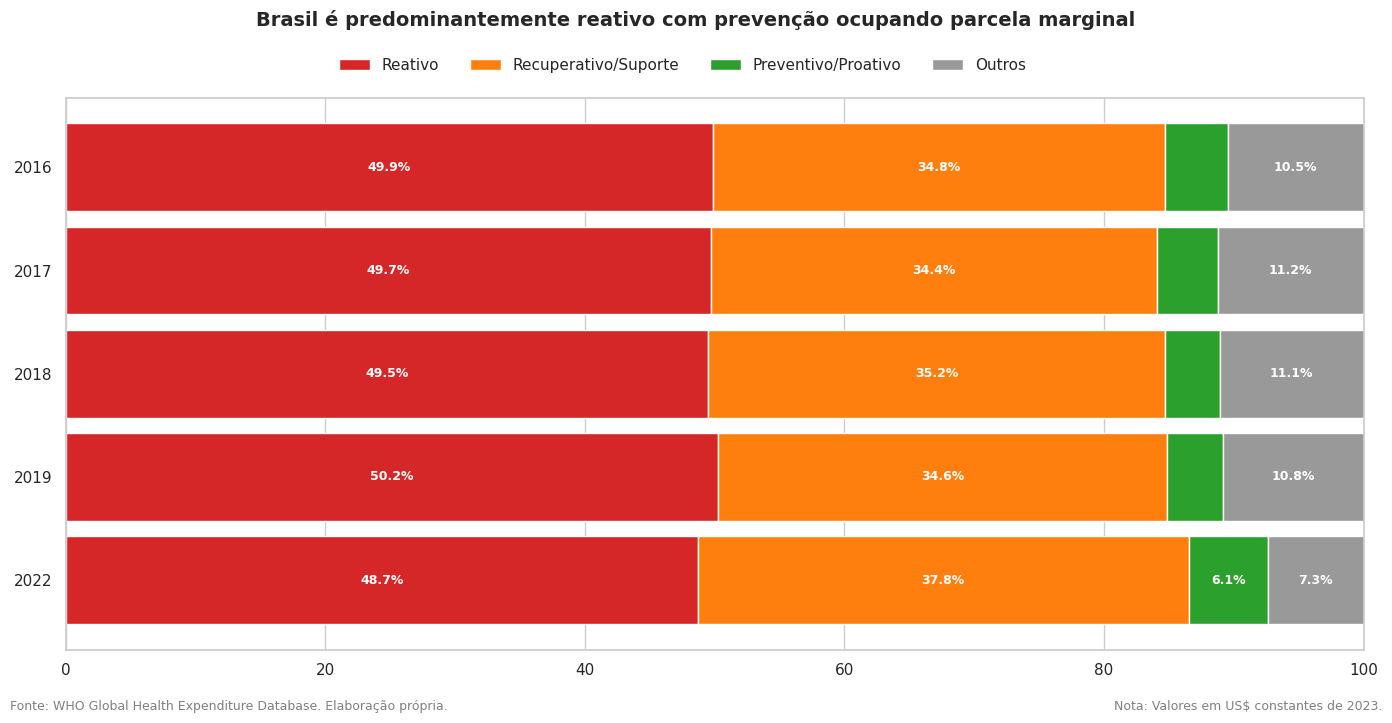

In [40]:
# Grafico 17: Evolução dos gasto por categoria
ORDEM_GRUPOS = ["Reativo", "Recuperativo/Suporte", "Preventivo/Proativo", "Outros"]

def calcular_pct_grupo(df):
    g = (
        df[df["indicator_code"].isin(INDICADORES_SP_ABS)]
        .groupby(["year", "grupo"])["value"]
        .sum()
        .reset_index()
    )
    g["pct"] = g.groupby("year")["value"].transform(lambda x: x / x.sum() * 100)
    return g

df_sp_pct_grupo = calcular_pct_grupo(df_sp_brasil)

df_sp_pct_pivot = (
    df_sp_pct_grupo
    .pivot(index="year", columns="grupo", values="pct")
    .reset_index()
    [["year"] + ORDEM_GRUPOS]
)

ax = df_sp_pct_pivot.set_index("year")[ORDEM_GRUPOS].plot(
    kind="barh", stacked=True,
    figsize=(14, 7), color=CORES_SP_GRUP, width=0.85,
)

adicionar_rotulos_internos(ax, threshold=5)
ax.invert_yaxis()
plt.xlim(0, 100)

plt.suptitle(
    "Brasil é predominantemente reativo com prevenção ocupando parcela marginal",
    fontsize=14, weight="bold",
)

plt.xlabel("")
plt.ylabel("")

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.2, 1.02),
    ncol=4,
    frameon=False,
)

adicionar_fonte()

plt.tight_layout()
plt.show()

In [41]:
# Calcular a razao HC1/HC6 para 2022 (último ano disponível)
df_sp_razao = (
    df_sp_brasil[
        (df_sp_brasil["year"] == 2022) &
        (df_sp_brasil["indicator_code"].isin(["hc1_usd2023", "hc6_usd2023"]))
    ]
    [["indicator_code", "value"]]
    .set_index("indicator_code")
)

razao = df_sp_razao.loc["hc1_usd2023", "value"] / df_sp_razao.loc["hc6_usd2023", "value"]
print(f"Em 2022, para cada U$D1 gasto em prevenção, o Brasil gasta U$D1{razao:.0f} em assistencia curativa")

Em 2022, para cada U$D1 gasto em prevenção, o Brasil gasta U$D18 em assistencia curativa


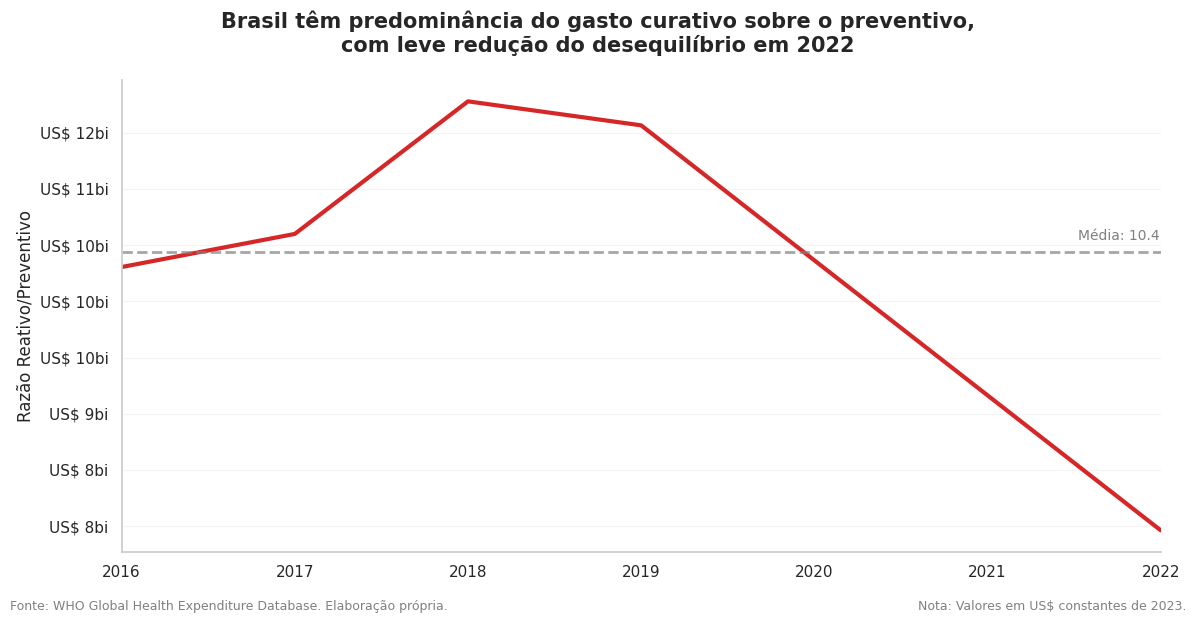

In [42]:
# Gráfico 18: Razão HC1/HC6
# Filtrar apenas os indicadores necessários
df_razao = df_sp_brasil[
    df_sp_brasil["indicator_code"].isin(["hc1_usd2023", "hc6_usd2023"])
].copy()

# Pivot para ter HC1 e HC6 em colunas
df_razao_pivot = (
    df_razao
    .pivot(index="year", columns="indicator_code", values="value")
    .reset_index()
    .rename(columns={
        "hc1_usd2023": "Reativo",
        "hc6_usd2023": "Prevenção"
    })
)

# Criar razão
df_razao_pivot["Razao"] = df_razao_pivot["Reativo"] / df_razao_pivot["Prevenção"]
media_razao = df_razao_pivot["Razao"].mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_razao_pivot["year"],
    df_razao_pivot["Razao"],
    linewidth=3,
    color=CORES["oop"],
    label="HC1 / HC6"
)

ax.axhline(
    media_razao,
    linestyle="--",
    linewidth=2,
    color="gray",
    alpha=0.7,
    label=f"Média ({media_razao:.1f})"
)

# Título
fig.suptitle(
    "Brasil têm predominância do gasto curativo sobre o preventivo,\ncom leve redução do desequilíbrio em 2022",
    fontsize=15,
    fontweight="bold"
)

ax.text(
    0.92, 0.67,
    f"Média: {media_razao:.1f}",
    transform=ax.transAxes,
    ha="left",
    va="center",
    color="gray",
    fontsize=10
)

ax.yaxis.set_major_formatter(FMT_BI)

ax.set_xlabel("")
ax.set_ylabel("Razão Reativo/Preventivo")

ax.set_xlim(df_razao_pivot["year"].min(), df_razao_pivot["year"].max())

ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", visible=False)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

adicionar_fonte()

plt.tight_layout()
plt.show()

#### Brasil x BRICS x Países Universais


In [43]:
# Verificar anos com dados completos para todos os paises
def anos_comuns(df, lista_paises):
    contagem = (
        df[df["country_name"].isin(lista_paises)]
        .groupby("year")["country_name"]
        .nunique()
    )
    return contagem[contagem == len(lista_paises)].index.tolist()

anos_brics     = anos_comuns(df_sp_brics,     PAISES_BRICS)
anos_universal = anos_comuns(df_sp_universal, PAISES_UNIVERSAL)

print(f"Anos comuns BRICS:    {anos_brics[-5:]}")
print(f"Anos comuns Universal: {anos_universal[-5:]}")

Anos comuns BRICS:    [2018, 2019]
Anos comuns Universal: [2016, 2017, 2018, 2019, 2022]


In [44]:
def grafico_perfil_comparado(df, lista_paises, ano, titulo):
    df_ano = (
        df[
            (df["year"] == ano) &
            (df["country_name"].isin(lista_paises)) &
            (df["indicator_code"].isin(INDICADORES_SP_ABS))
        ]
        .groupby(["country_name", "grupo"])["value"]
        .sum()
        .reset_index()
    )
    df_ano["pct"] = (
        df_ano.groupby("country_name")["value"]
        .transform(lambda x: x / x.sum() * 100)
    )
    df_ano = df_ano.pipe(traduzir_paises)

    pivot = (
        df_ano
        .pivot(index="country_name", columns="grupo", values="pct")
        .reset_index()
    )
    # Garantir todas as colunas existem
    for col in ORDEM_GRUPOS:
        if col not in pivot.columns:
            pivot[col] = 0.0
    pivot = pivot.sort_values("Preventivo/Proativo", ascending=False)

    ax = pivot.set_index("country_name")[ORDEM_GRUPOS].plot(
        kind="barh", stacked=True,
        figsize=(14, 7), color=CORES_SP_GRUP, width=0.85,
    )

    adicionar_rotulos_internos(ax, threshold=5)

    plt.xlim(0, 100)

    plt.suptitle(titulo, fontsize=14, weight="bold")

    plt.xlabel("")
    plt.ylabel("")

    ax.legend(
        loc="lower left",
        bbox_to_anchor=(0.2, 1.02),
        ncol=4,
        frameon=False,
    )

    adicionar_fonte()

    plt.tight_layout()
    plt.show()

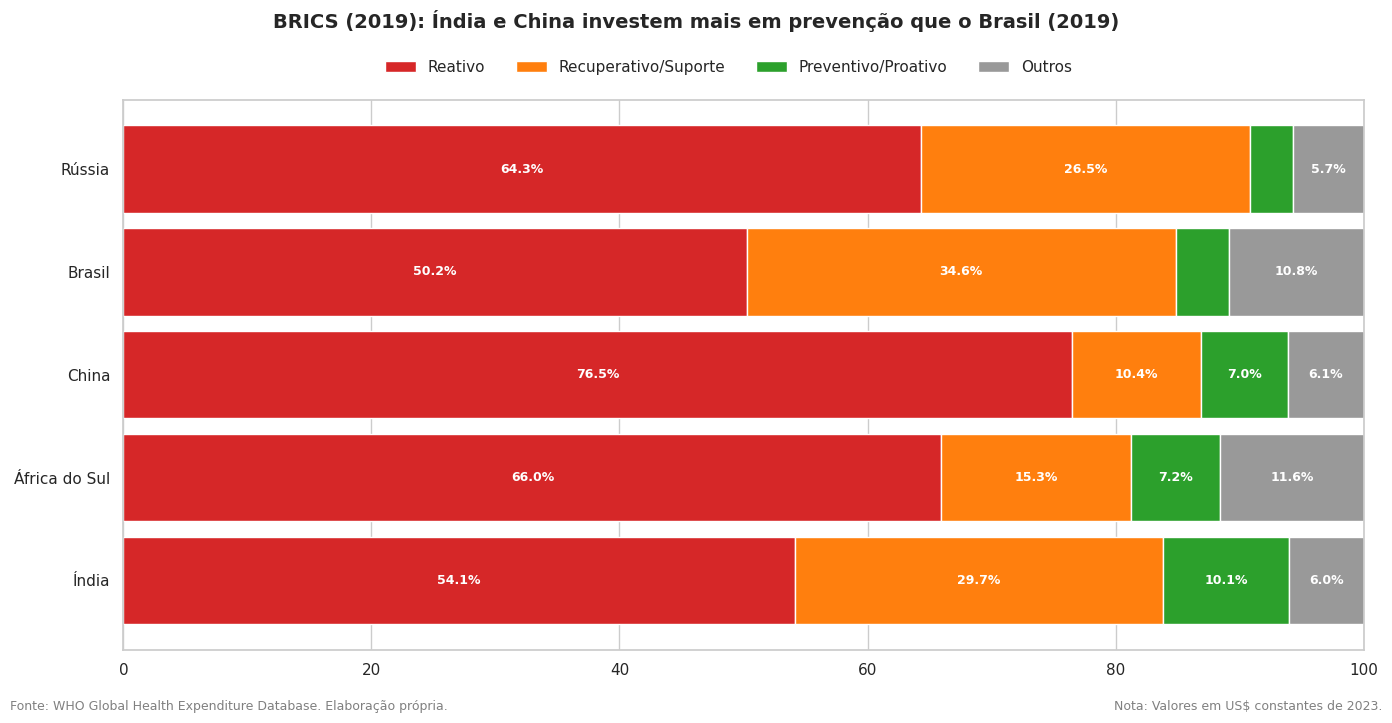

In [45]:
# Grafico 19: BRICS — ano mais recente com dados completos
ano_brics = max(anos_brics)

grafico_perfil_comparado(
    df_sp_brics, PAISES_BRICS, ano_brics,
    f"BRICS ({ano_brics}): Índia e China investem mais em prevenção que o Brasil (2019)"
)

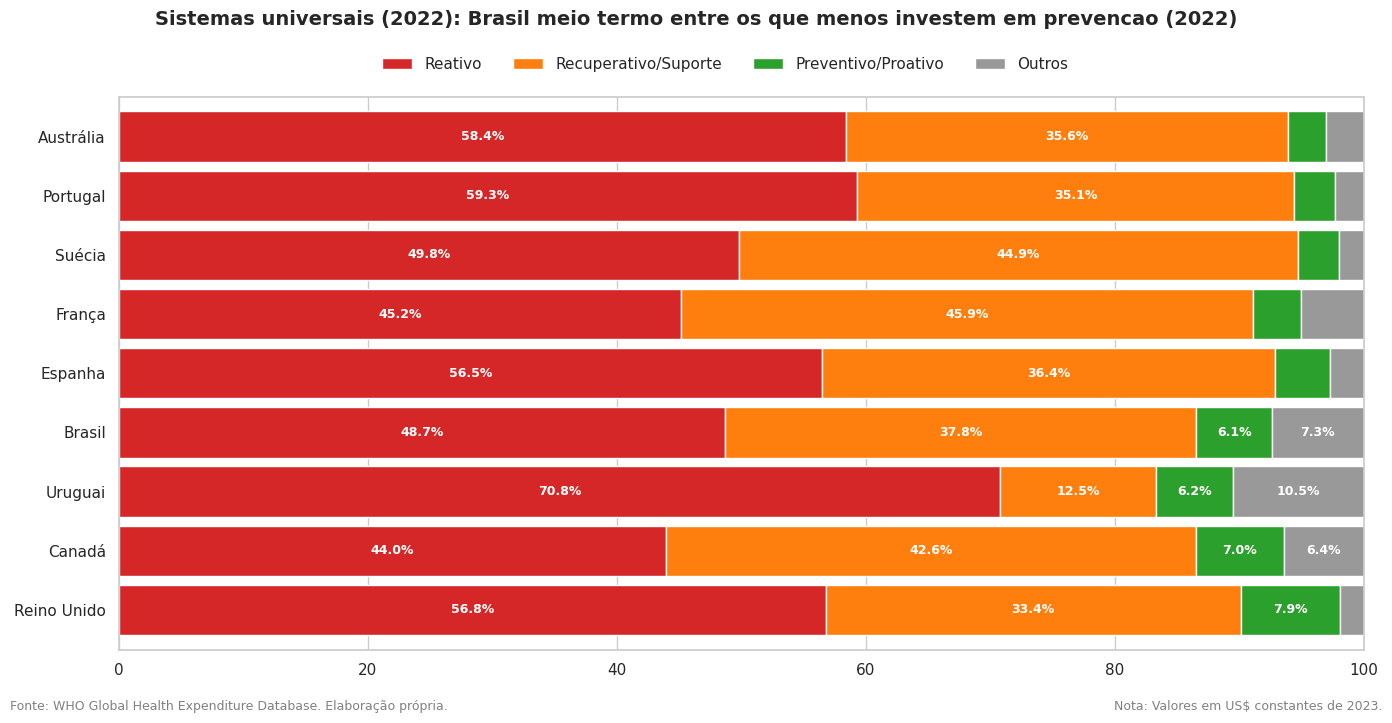

In [46]:
# Grafico: Sistemas universais — ano mais recente com dados completos
ano_univ = max(anos_universal)

grafico_perfil_comparado(
    df_sp_universal, PAISES_UNIVERSAL, ano_univ,
    f"Sistemas universais ({ano_univ}): Brasil meio termo entre os que menos investem em prevencao (2022)"
)